# Sprint ML Analysis

Loads pre-processed stride vectors from `Kinematics_PCA.ipynb`, runs
functional PCA (sklearn), biomechanics metrics, model comparison,
feature importance, split-time prediction, and sex analysis.
PC shape-mode figures are generated by this notebook (no MATLAB required).

**Pre-requisites**: run `Kinematics_PCA.ipynb` first (saves `.npy` / `.csv` / `.pkl`).


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle, time, warnings
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
warnings.filterwarnings('ignore')
np.random.seed(42)

from scipy.stats import pearsonr, mannwhitneyu
from scipy.signal import find_peaks, savgol_filter
from sklearn.decomposition import PCA
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   BayesianRidge, RidgeCV, LassoCV, ElasticNetCV,
                                   HuberRegressor)
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict, cross_val_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.utils import resample
import statsmodels.api as sm
import xgboost as xgb
import shap

RANDOM_SEED = 42
print("Imports OK")


Imports OK


In [2]:
# ── Paths & load saved data ───────────────────────────────────────────────────
SCRIPT_DIR = Path("/Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code")
DATA_DIR   = SCRIPT_DIR / "Outputs" / "Data"
FIG_DIR    = SCRIPT_DIR / "Outputs" / "Figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

dataset       = np.load(DATA_DIR / 'participant_vectors.npy')
accel_dataset = np.load(DATA_DIR / 'accel_participant_vectors.npy')
meta_df       = pd.read_csv(DATA_DIR / 'metadata.csv')
accel_meta    = pd.read_csv(DATA_DIR / 'accel_metadata.csv')

with open(DATA_DIR / 'velocity_traces.pkl', 'rb') as f:
    velocity_traces = pickle.load(f)

pid_order  = meta_df['participant_id'].tolist()
y          = meta_df['max_velocity_ms'].values

# TN_POINTS / N_MARKERS_C3D inferred from data
SAMPLING_RATE = 60
TN_POINTS     = 101
N_MARKERS_C3D = 64

print(f"dataset       : {dataset.shape}")
print(f"accel_dataset : {accel_dataset.shape}")
print(f"meta_df       : {meta_df.shape}")
print(f"velocity_traces: {len(velocity_traces)} participants")

# ── Fit PCA (sklearn) on stride-vector matrices ─────────────────────────────
# Data is loaded from PCA_handoff.mat / Outputs/Data/ (both have identical
# participant vectors, so sklearn PCA is the single canonical path).
mu        = dataset.mean(0)
fpca      = PCA(n_components=min(30, dataset.shape[0]-1, dataset.shape[1]),
                random_state=RANDOM_SEED)
scores    = fpca.fit_transform(dataset - mu)

ac_mu       = accel_dataset.mean(0)
accel_fpca  = PCA(n_components=min(30, accel_dataset.shape[0]-1, accel_dataset.shape[1]),
                  random_state=RANDOM_SEED)
accel_scores = accel_fpca.fit_transform(accel_dataset - ac_mu)
print(f"PCA fit — top-speed: {scores.shape}  accel: {accel_scores.shape}")

# Pick retained PCs by stepwise regression
def stepwise_pcs(scores_mat, y_vec, max_pcs=3, p_thresh=0.10):
    selected, remaining = [], list(range(scores_mat.shape[1]))
    for _ in range(max_pcs):
        best_p, best_pc = 1.0, None
        for pc in remaining:
            res = sm.OLS(y_vec, sm.add_constant(scores_mat[:, selected+[pc]])).fit()
            if res.pvalues[-1] < best_p:
                best_p, best_pc = res.pvalues[-1], pc
        if best_pc is not None and best_p < p_thresh:
            selected.append(best_pc); remaining.remove(best_pc)
        else:
            break
    return selected or [int(np.argmax([abs(pearsonr(scores_mat[:,i], y_vec)[0])
                                       for i in range(scores_mat.shape[1])]))]

RETAINED_PCS = stepwise_pcs(scores, y)
print(f"Retained PCs (top-speed): {[p+1 for p in RETAINED_PCS]}")

y_accel = accel_meta['max_velocity'].values
RETAINED_ACCEL_PCS = stepwise_pcs(accel_scores, y_accel)
print(f"Retained PCs (accel):     {[p+1 for p in RETAINED_ACCEL_PCS]}")


dataset       : (30, 19392)
accel_dataset : (26, 19392)
meta_df       : (30, 6)
velocity_traces: 30 participants
PCA fit — top-speed: (30, 29)  accel: (26, 25)
Retained PCs (top-speed): [2, 6, 9]
Retained PCs (accel):     [5, 9, 7]


---
## Biomechanics Metrics


In [3]:
# ── Reconstruction helper (for fPCA cells below) ──────────────────────────────
def vector_to_frames(vector, n_frames=TN_POINTS):
    n_mk = len(vector) // (3 * n_frames)
    L = n_mk * n_frames
    x = vector[    :  L].reshape(n_mk, n_frames).T
    y = vector[  L :2*L].reshape(n_mk, n_frames).T
    z = vector[2*L :   ].reshape(n_mk, n_frames).T
    return np.stack([x, y, z], axis=-1)

print("Helpers loaded.")


Helpers loaded.


Generating PC shape-mode kinograms…


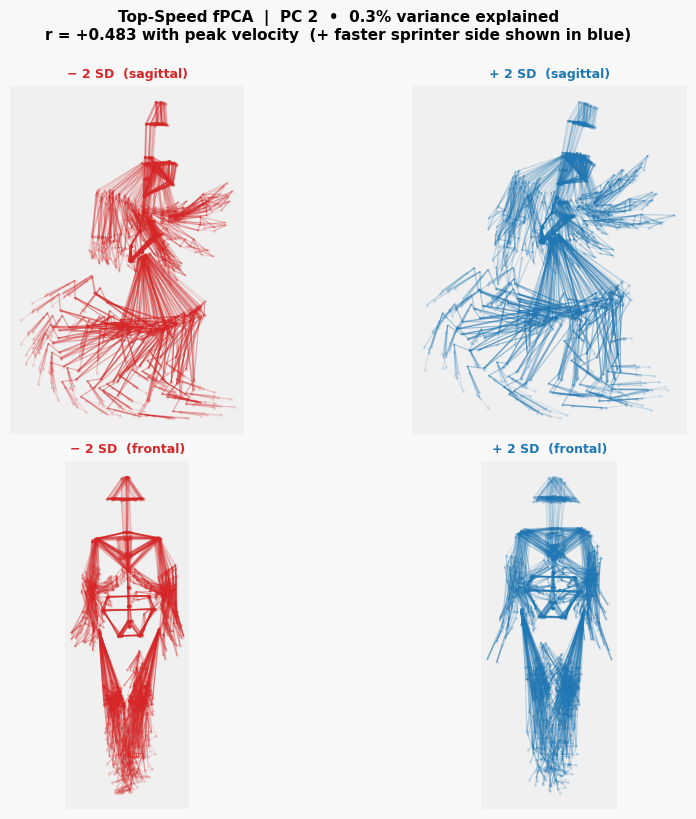

  Saved: top-speed_fpca_PC_2.png  (r=+0.483, EVR=0.3%)


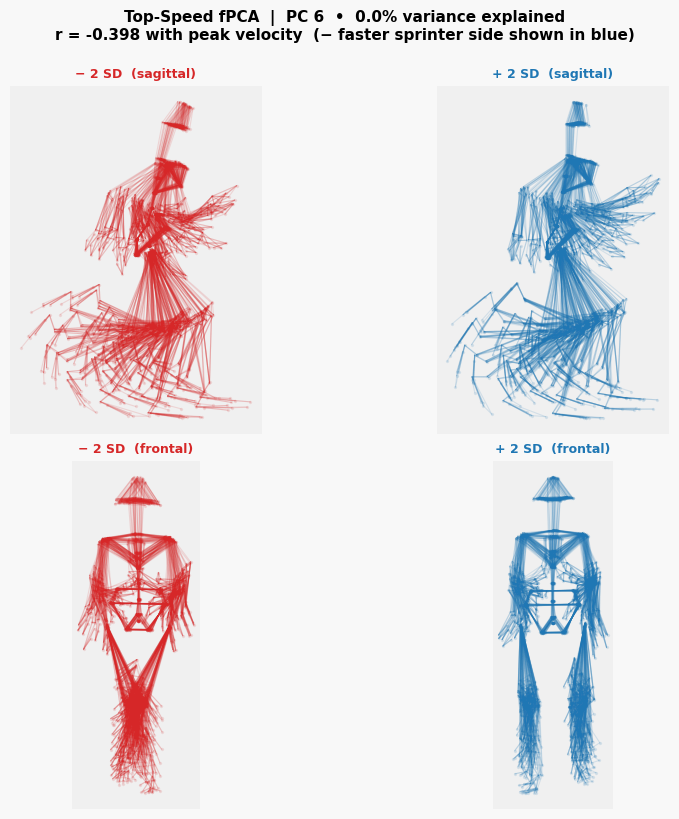

  Saved: top-speed_fpca_PC_6.png  (r=-0.398, EVR=0.0%)


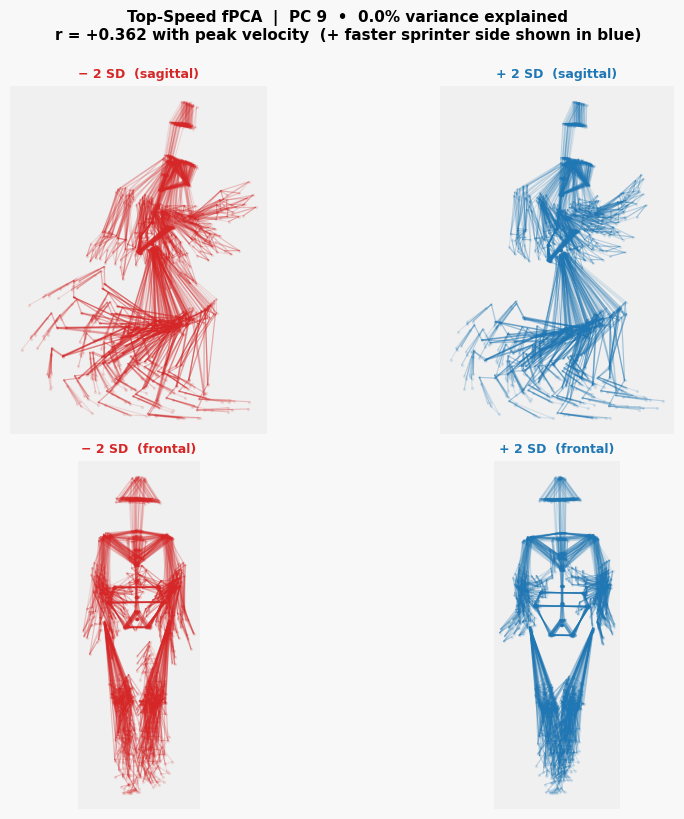

  Saved: top-speed_fpca_PC_9.png  (r=+0.362, EVR=0.0%)


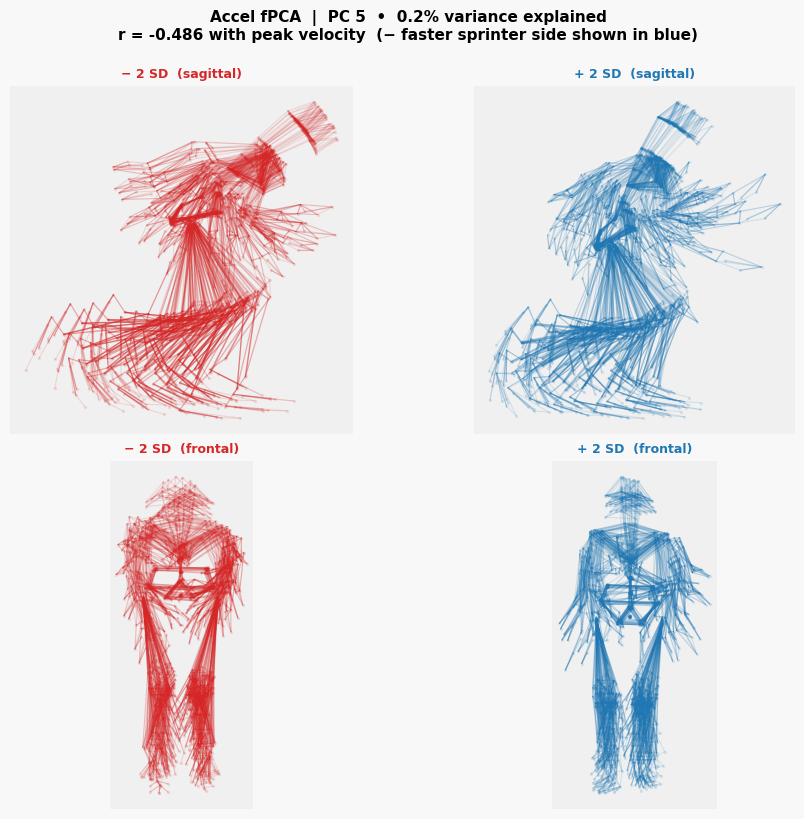

  Saved: accel_fpca_PC_5.png  (r=-0.486, EVR=0.2%)


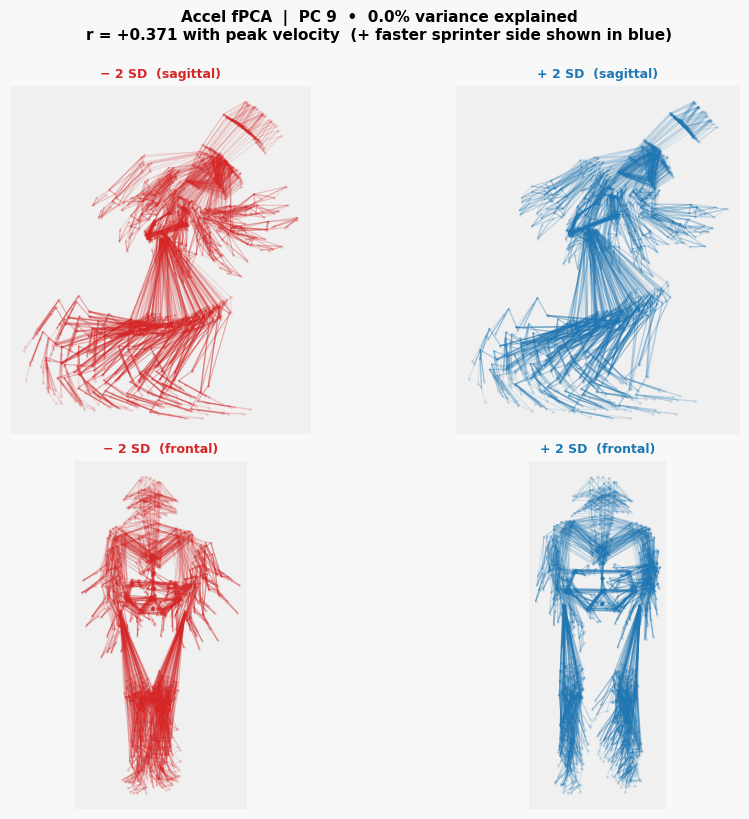

  Saved: accel_fpca_PC_9.png  (r=+0.371, EVR=0.0%)


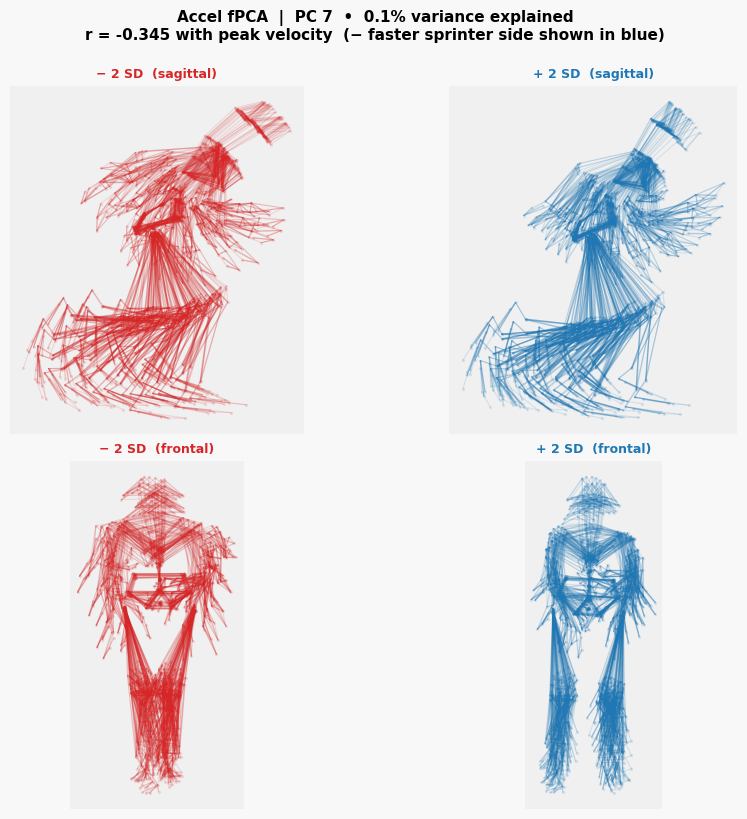

  Saved: accel_fpca_PC_7.png  (r=-0.345, EVR=0.1%)

PC figures: 3 top-speed + 3 accel
These replace the MATLAB sprint_fPCA_figures.m output.


In [4]:
# ── PC Shape-Mode Kinograms (replaces MatLab sprint_fPCA_figures.m) ─────────
# For each retained PC, reconstructs the mean stride ±2 SD along that PC axis
# and draws sagittal + frontal MCR kinograms (all 101 frames overlaid).
# Saves: Outputs/Figures/topspeed_PC_{n}.png  and  accel_PC_{n}.png

# ── 64-marker bone polylines (0-based, XSens 64-sensor suit) ─────────────────
_BONES = [
    [1,2,4,3,1,5,6,2,6,7,5,7,8,9,10,13,15,20,11,14,10,14,20,14,21,14,11,21,15],
    [21,10],[20,10],[16,17,18,16,19,17,19,18,19,15],
    [20,22,23,28,23,20],[20,28,26,28,27,26],
    [23,26,23,27,26],[22,26,22,27,26],
    [26,32,27,32,33,32,34,32,33,26],
    [21,24,25,24,31,21],[21,25],
    [29,30,24,29,24,30,24,25,29,25,30,25],[31,29,30,29,31,30,31],
    [29,35,29,36,29,37,35,36,30,35,30,36,30,37,30],
    [38,39,38,40,38,41,40,39,41,46,39,46,40,46],
    [46,47,46,48],[39,47,39,48],[40,47,40,48],
    [47,48,52,47,52,53,52,54,52,55,56,55,57,52],
    [42,43,42,44,42,45,44,43,45],[49,45,49,44,49,43,49],
    [49,50,49,51,49],[43,50,43,51,43],[44,50,44,51,44],
    [50,51,50,58,51,58,59,58,59,58,61,58,60,61,62,61,63],
]
_MK_PELVIS_PC = [0,1,2,3,4,5,6]
_AP_PC, _ML_PC, _VT_PC = 0, 1, 2   # forward, lateral, up

def _draw_mcr_pc(ax, frames, plane='sagittal', color='k', alpha=0.14,
                 lw=0.8, n_mcr=25):
    """Draw n_mcr evenly-spaced frames from (101,64,3) as ghost overlay."""
    idxs = np.linspace(0, frames.shape[0]-1, n_mcr).astype(int)
    for fi in idxs:
        fr  = frames[fi] * 1000.0            # height-normalised → mm-equivalent
        fr -= np.mean(fr[_MK_PELVIS_PC], axis=0)   # centre on pelvis
        hh  = fr[:, _AP_PC] if plane == 'sagittal' else fr[:, _ML_PC]
        vv  = fr[:, _VT_PC]
        for bone in _BONES:
            for j in range(len(bone)-1):
                a, b = bone[j], bone[j+1]
                if a < 64 and b < 64:
                    ax.plot([hh[a], hh[b]], [vv[a], vv[b]],
                            color=color, alpha=alpha, lw=lw,
                            solid_capstyle='round')
        ax.scatter(hh, vv, s=2, c=color, alpha=alpha*0.7, zorder=5)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_facecolor('#f0f0f0')


def _pc_figure(ds, pca, mu, pc_idx, y_target, prefix, fig_dir):
    """Generate and save one PC shape-mode figure."""
    from scipy.stats import pearsonr as _pr
    pc_vec     = pca.components_[pc_idx]
    scores_arr = pca.transform(ds - mu)[:, pc_idx]
    std_i      = scores_arr.std()
    r, _       = _pr(scores_arr, y_target)
    evr        = pca.explained_variance_ratio_[pc_idx] * 100

    fr_neg = vector_to_frames(mu + (-2 * std_i) * pc_vec)
    fr_pos = vector_to_frames(mu + ( 2 * std_i) * pc_vec)

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.patch.set_facecolor('#f8f8f8')
    config = [
        (axes[0,0], fr_neg, 'sagittal', '#d62728', '\u2212 2 SD  (sagittal)'),
        (axes[0,1], fr_pos, 'sagittal', '#1f77b4', '+ 2 SD  (sagittal)'),
        (axes[1,0], fr_neg, 'frontal',  '#d62728', '\u2212 2 SD  (frontal)'),
        (axes[1,1], fr_pos, 'frontal',  '#1f77b4', '+ 2 SD  (frontal)'),
    ]
    for ax, fr, plane, col, ttl in config:
        _draw_mcr_pc(ax, fr, plane=plane, color=col)
        ax.set_title(ttl, fontsize=9, color=col, fontweight='bold')

    sign_str = '+ faster' if r > 0 else '\u2212 faster'
    fig.suptitle(
        f'{prefix}  |  PC {pc_idx+1}  \u2022  {evr:.1f}% variance explained\n'
        f'r = {r:+.3f} with peak velocity  '
        f'({sign_str} sprinter side shown in blue)',
        fontsize=11, fontweight='bold', y=1.01
    )
    plt.tight_layout(pad=0.6)
    out = fig_dir / f'{prefix.lower().replace(" ","_")}_PC_{pc_idx+1}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Saved: {out.name}  (r={r:+.3f}, EVR={evr:.1f}%)")
    return out


print("Generating PC shape-mode kinograms…")
_saved_ts = []
for pc_i in RETAINED_PCS:
    _saved_ts.append(_pc_figure(dataset, fpca, mu, pc_i, y,
                                'Top-Speed fPCA', FIG_DIR))

_saved_ac = []
for pc_i in RETAINED_ACCEL_PCS:
    _saved_ac.append(_pc_figure(accel_dataset, accel_fpca, ac_mu, pc_i,
                                y_accel, 'Accel fPCA', FIG_DIR))

print(f"\nPC figures: {len(_saved_ts)} top-speed + {len(_saved_ac)} accel")
print("These replace the MATLAB sprint_fPCA_figures.m output.")


In [5]:
# ── Load biomechanics metrics (computed by Kinematics_PCA.ipynb) ──────────────
bio_full = pd.read_csv(DATA_DIR / 'sprint_biomechanics_metrics.csv')
bio_numeric_cols = [c for c in bio_full.columns
                    if bio_full[c].dtype in ['float64','int64','int32']
                    and c not in ('participant_id',)]
print(f"Loaded bio_full  {bio_full.shape}  ({len(bio_numeric_cols)} numeric cols)")
bio_full.head(3)

# Build dict view for code that expects {pid: {metric: value}}
biomechanics = bio_full.set_index('participant_id').to_dict('index')


Loaded bio_full  (30, 14)  (11 numeric cols)


## Biomechanics Visualisations


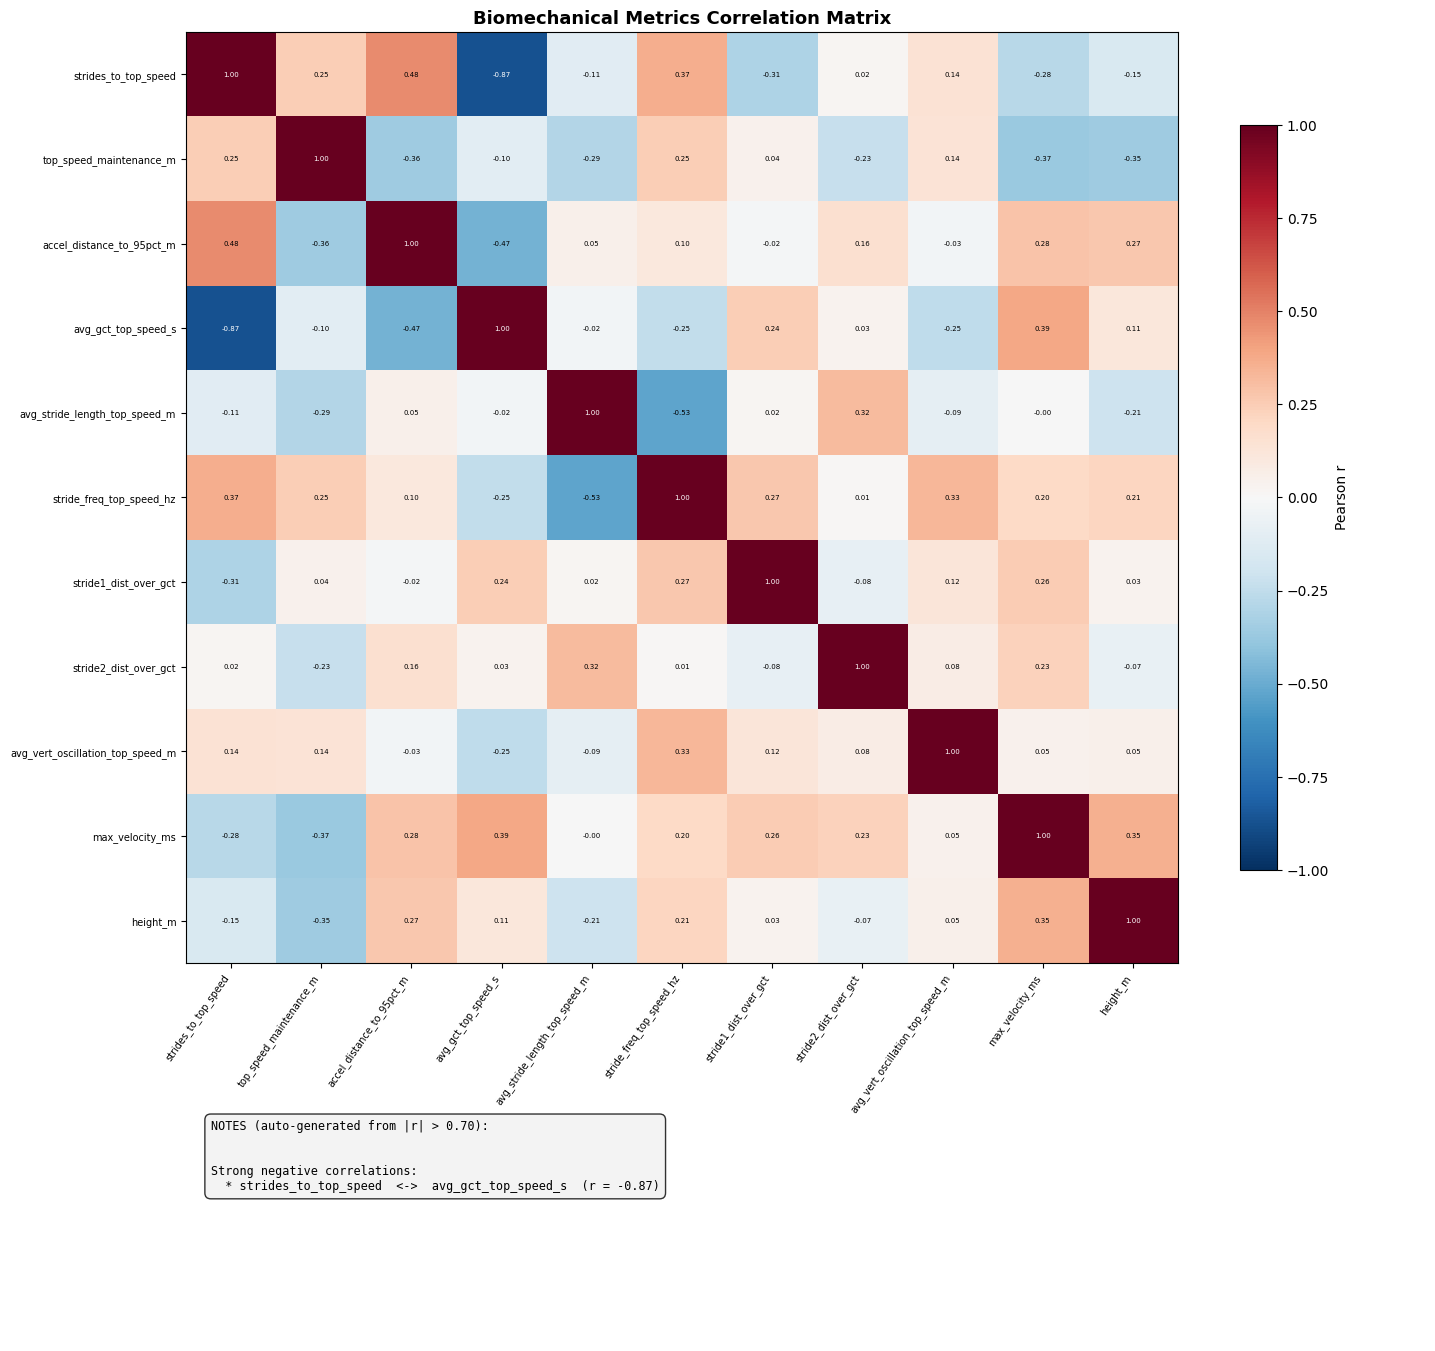

In [6]:
# -- Correlation heatmap: all numeric metrics (with auto-generated notes) --
numeric_cols = [c for c in bio_full.columns
                if bio_full[c].dtype in ['float64', 'int64', 'int32']
                and c != 'participant_id']
corr = bio_full[numeric_cols].corr()

fig = plt.figure(figsize=(16, 17))
gs  = fig.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.25)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=55, ha='right', fontsize=7)
ax.set_yticklabels(numeric_cols, fontsize=7)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=5, color=color)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_title('Biomechanical Metrics Correlation Matrix', fontweight='bold', fontsize=13)

# -- Auto-generate notes: strong correlations --
strong_pos, strong_neg = [], []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        r = corr.iloc[i, j]
        pair = f"{numeric_cols[i]}  <->  {numeric_cols[j]}"
        if r > 0.7:
            strong_pos.append((pair, r))
        elif r < -0.7:
            strong_neg.append((pair, r))
strong_pos.sort(key=lambda x: x[1], reverse=True)
strong_neg.sort(key=lambda x: x[1])

notes_lines = ["NOTES (auto-generated from |r| > 0.70):", ""]
if strong_pos:
    notes_lines.append("Strong positive correlations:")
    for pair, r in strong_pos[:8]:
        notes_lines.append(f"  * {pair}  (r = {r:+.2f})")
if strong_neg:
    notes_lines.append("")
    notes_lines.append("Strong negative correlations:")
    for pair, r in strong_neg[:8]:
        notes_lines.append(f"  * {pair}  (r = {r:+.2f})")
if not strong_pos and not strong_neg:
    notes_lines.append("  No metric pairs exceed |r| > 0.70.")

ax_notes = fig.add_subplot(gs[1])
ax_notes.axis('off')
ax_notes.text(0.02, 0.95, '\n'.join(notes_lines),
              transform=ax_notes.transAxes, fontsize=8.5, fontfamily='monospace',
              verticalalignment='top',
              bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.8))

fig.savefig(str(FIG_DIR / 'biomechanics_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()


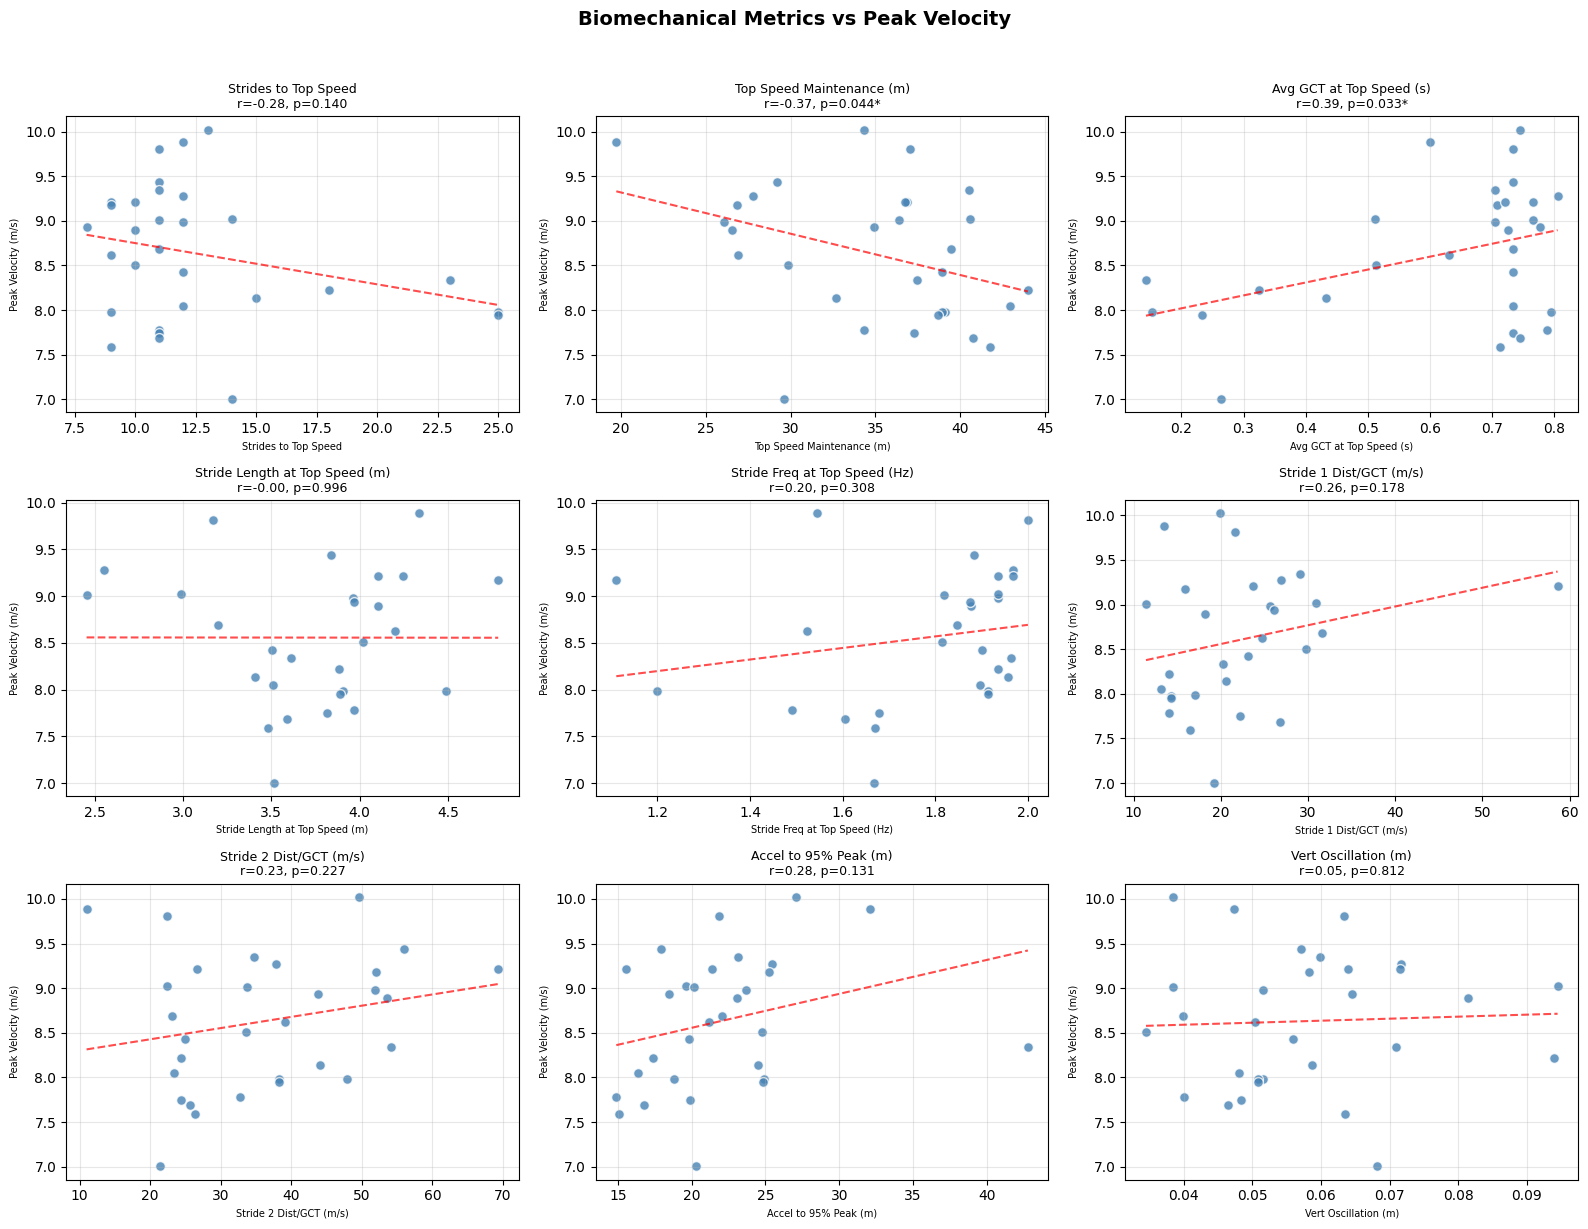

In [7]:
# ── Key metrics vs peak velocity scatter plots ──────────────
scatter_metrics = [
    ('strides_to_top_speed', 'Strides to Top Speed'),
    ('top_speed_maintenance_m', 'Top Speed Maintenance (m)'),
    ('avg_gct_top_speed_s', 'Avg GCT at Top Speed (s)'),
    ('avg_stride_length_top_speed_m', 'Stride Length at Top Speed (m)'),
    ('stride_freq_top_speed_hz', 'Stride Freq at Top Speed (Hz)'),
    ('stride1_dist_over_gct', 'Stride 1 Dist/GCT (m/s)'),
    ('stride2_dist_over_gct', 'Stride 2 Dist/GCT (m/s)'),
    ('accel_distance_to_95pct_m', 'Accel to 95% Peak (m)'),
    ('avg_vert_oscillation_top_speed_m', 'Vert Oscillation (m)'),
]

n_plots = len(scatter_metrics)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, (col, label) in enumerate(scatter_metrics):
    ax = axes[idx]
    x = bio_full[col].values.astype(float)
    y = bio_full['max_velocity_ms'].values.astype(float)
    mask = np.isfinite(x) & np.isfinite(y) & (x != 0)
    ax.scatter(x[mask], y[mask], c='steelblue', edgecolors='white', s=50, alpha=0.8)
    if mask.sum() > 2:
        r, p = pearsonr(x[mask], y[mask])
        z = np.polyfit(x[mask], y[mask], 1)
        poly = np.poly1d(z)
        x_line = np.linspace(x[mask].min(), x[mask].max(), 50)
        ax.plot(x_line, poly(x_line), 'r--', alpha=0.7, lw=1.5)
        sig = '*' if p < 0.05 else ''
        ax.set_title(f'{label}\nr={r:.2f}, p={p:.3f}{sig}', fontsize=9)
    else:
        ax.set_title(label, fontsize=9)
    ax.set_xlabel(label, fontsize=7)
    ax.set_ylabel('Peak Velocity (m/s)', fontsize=7)
    ax.grid(alpha=0.3)

for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Biomechanical Metrics vs Peak Velocity',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'biomechanics_vs_velocity.png'), dpi=150, bbox_inches='tight')
plt.show()


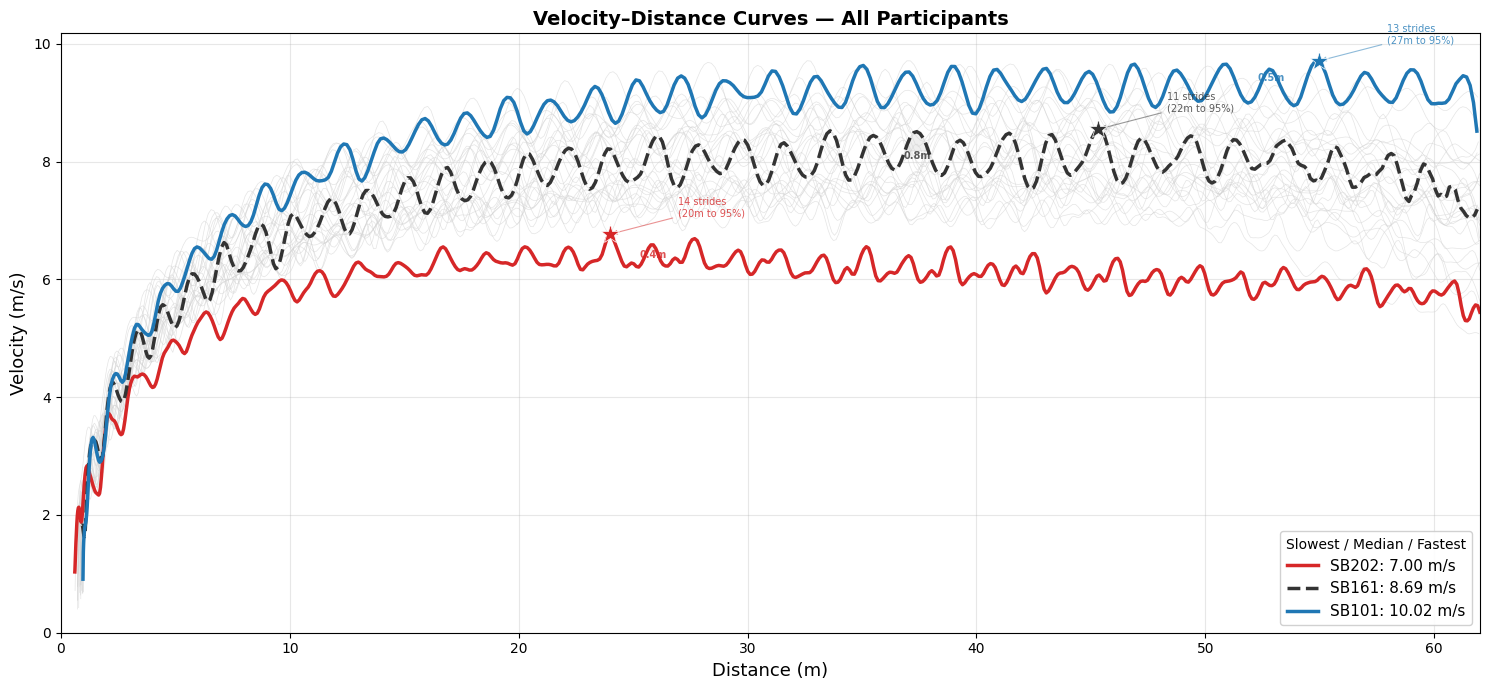

Peak velocities:
  Slowest (SB202): 7.00 m/s
  Median  (SB161):  8.69 m/s
  Fastest (SB101): 10.02 m/s


In [8]:
# -- Velocity-Distance Curves (Enhanced Figure 4) --
from scipy.signal import savgol_filter

COLOR_SLOW = '#d62728'   # red
COLOR_MEAN = '#333333'   # black
COLOR_FAST = '#1f77b4'   # blue

sorted_pids = sorted(velocity_traces.keys(),
                     key=lambda p: velocity_traces[p]['peak_vel'])
n_pids = len(sorted_pids)

slowest_pid = sorted_pids[0]
median_pid  = sorted_pids[n_pids // 2]
fastest_pid = sorted_pids[-1]

fig, ax = plt.subplots(figsize=(15, 7))

# All traces in grey (smoothed)
for pid in sorted_pids:
    vt = velocity_traces[pid]
    d, v = np.asarray(vt['distance_m']), np.asarray(vt['velocity_ms'])
    win = min(11, max(5, len(v)//2*2-1))
    if win >= 5 and len(v) >= win:
        v_smooth = savgol_filter(v, win, 3)
    else:
        v_smooth = v
    ax.plot(d, v_smooth, color='lightgrey', lw=0.5, alpha=0.6)

# Highlight 3 key traces with peak markers + maintenance zones
for pid, color, ls in [(slowest_pid, COLOR_SLOW, '-'),
                        (median_pid,  COLOR_MEAN, '--'),
                        (fastest_pid, COLOR_FAST, '-')]:
    vt = velocity_traces[pid]
    d, v = np.asarray(vt['distance_m']), np.asarray(vt['velocity_ms'])
    peak_v = vt['peak_vel']

    win = min(11, max(5, len(v)//2*2-1))
    if win >= 5 and len(v) >= win:
        v_smooth = savgol_filter(v, win, 3)
    else:
        v_smooth = v.copy()

    ax.plot(d, v_smooth, color=color, lw=2.5, ls=ls,
            label=f'{pid}: {peak_v:.2f} m/s')

    # Mark peak velocity with star
    peak_idx = int(np.argmax(v_smooth))
    ax.plot(d[peak_idx], v_smooth[peak_idx], marker='*', color=color,
            markersize=14, zorder=10, markeredgecolor='white', markeredgewidth=0.5)

    # Top speed maintenance zone (>= peak_vel - 0.5 m/s)
    thresh = peak_v - 0.5
    above = v >= thresh
    runs = []
    run_start = None
    for i, val in enumerate(above):
        if val and run_start is None:
            run_start = i
        elif not val and run_start is not None:
            runs.append((run_start, i - 1))
            run_start = None
    if run_start is not None:
        runs.append((run_start, len(above) - 1))

    if runs:
        longest = max(runs, key=lambda r: r[1] - r[0])
        maint_d0 = d[longest[0]]
        maint_d1 = d[longest[1]]
        maint_dist = maint_d1 - maint_d0
        # Shaded maintenance zone
        ax.fill_between(d[longest[0]:longest[1]+1],
                        thresh, v_smooth[longest[0]:longest[1]+1],
                        alpha=0.08, color=color)
        ax.annotate(f'{maint_dist:.1f}m', xy=((maint_d0+maint_d1)/2, thresh-0.15),
                    fontsize=7, color=color, ha='center', alpha=0.8, fontweight='bold')

    # Strides to top speed annotation
    if pid in biomechanics:
        strides_ts = biomechanics[pid]['strides_to_top_speed']
        accel_d = biomechanics[pid]['accel_distance_to_95pct_m']
        ax.annotate(f'{strides_ts} strides\n({accel_d:.0f}m to 95%)',
                    xy=(d[peak_idx], v_smooth[peak_idx]),
                    xytext=(d[peak_idx]+3, v_smooth[peak_idx]+0.3),
                    fontsize=7, color=color, alpha=0.8,
                    arrowprops=dict(arrowstyle='->', color=color, alpha=0.5, lw=0.8))

ax.set_xlabel('Distance (m)', fontsize=13)
ax.set_ylabel('Velocity (m/s)', fontsize=13)
ax.set_title('Velocity\u2013Distance Curves \u2014 All Participants',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.9,
          title='Slowest / Median / Fastest')
ax.set_xlim(0, 62)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'velocity_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak velocities:')
print(f'  Slowest ({slowest_pid}): {velocity_traces[slowest_pid]["peak_vel"]:.2f} m/s')
print(f'  Median  ({median_pid}):  {velocity_traces[median_pid]["peak_vel"]:.2f} m/s')
print(f'  Fastest ({fastest_pid}): {velocity_traces[fastest_pid]["peak_vel"]:.2f} m/s')

---
## fPCA → Peak Velocity Regression


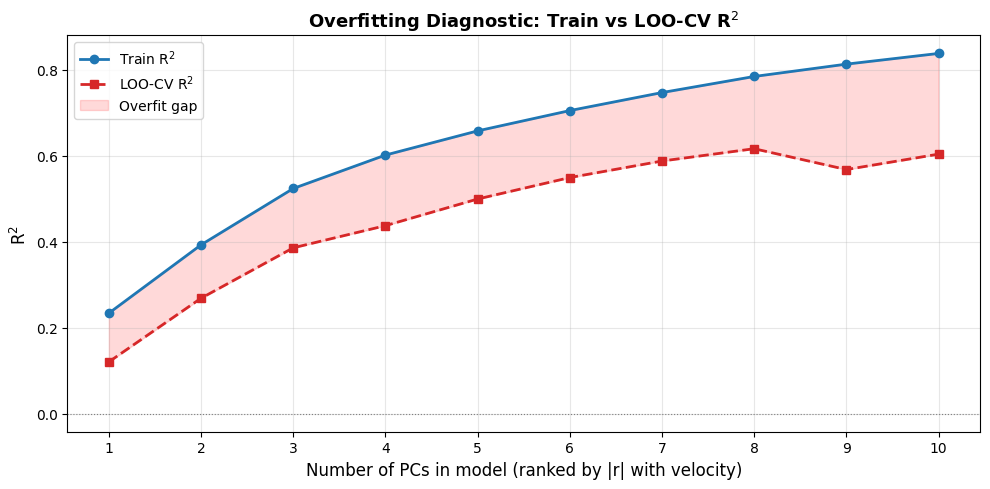

 PCs   Train R2   LOO-CV R2     Gap
-----------------------------------
   1      0.234       0.120     0.113
   2      0.392       0.268     0.124
   3      0.523       0.386     0.138
   4      0.601       0.437     0.164
   5      0.657       0.499     0.158
   6      0.705       0.549     0.156
   7      0.746       0.587     0.159
   8      0.784       0.616     0.168
   9      0.813       0.567     0.245
  10      0.837       0.603     0.234

Stepwise model (3 PCs): Train R2=0.523, LOO-CV R2=0.386
Recommendation: With n=31, models with >3 predictors are prone to overfitting.
LOO-CV is the honest performance estimate.


In [9]:
# -- Overfitting Analysis: Train vs LOO-CV R^2 by number of PCs --
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Sort all PCs by |correlation| with velocity (same ranking stepwise uses)
pc_cors = []
for i in range(scores.shape[1]):
    r_val, _ = pearsonr(scores[:, i], y)
    pc_cors.append((i, abs(r_val)))
pc_cors.sort(key=lambda x: x[1], reverse=True)
top_pcs_by_cor = [x[0] for x in pc_cors]

# Scan: add PCs one at a time (by |r| ranking), track train vs LOO-CV R^2
n_scan = min(10, len(top_pcs_by_cor))
train_r2s, loo_r2s = [], []
for k in range(1, n_scan + 1):
    pcs_k = top_pcs_by_cor[:k]
    X_k = scores[:, pcs_k]
    lr = LinearRegression()
    lr.fit(X_k, y)
    train_r2s.append(r2_score(y, lr.predict(X_k)))
    yp = cross_val_predict(lr, X_k, y, cv=LeaveOneOut())
    loo_r2s.append(r2_score(y, yp))

fig, ax = plt.subplots(figsize=(10, 5))
ks = range(1, n_scan + 1)
ax.plot(ks, train_r2s, 'o-', color='#1f77b4', lw=2, label='Train R$^2$')
ax.plot(ks, loo_r2s,   's--', color='#d62728', lw=2, label='LOO-CV R$^2$')
ax.fill_between(ks, loo_r2s, train_r2s, alpha=0.15, color='red', label='Overfit gap')
ax.axhline(0, color='grey', ls=':', lw=0.8)
ax.set_xlabel('Number of PCs in model (ranked by |r| with velocity)', fontsize=12)
ax.set_ylabel('R$^2$', fontsize=12)
ax.set_title('Overfitting Diagnostic: Train vs LOO-CV R$^2$', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(list(ks))
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'overfitting_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"{'PCs':>4s}  {'Train R2':>9s}  {'LOO-CV R2':>10s}  {'Gap':>6s}")
print("-" * 35)
for k, tr, lr2 in zip(ks, train_r2s, loo_r2s):
    print(f"  {k:2d}    {tr:7.3f}     {lr2:7.3f}    {tr-lr2:6.3f}")
print()
print(f"Stepwise model ({len(RETAINED_PCS)} PCs): Train R2={train_r2s[len(RETAINED_PCS)-1]:.3f}, LOO-CV R2={loo_r2s[len(RETAINED_PCS)-1]:.3f}")
print(f"Recommendation: With n=31, models with >3 predictors are prone to overfitting.")
print(f"LOO-CV is the honest performance estimate.")


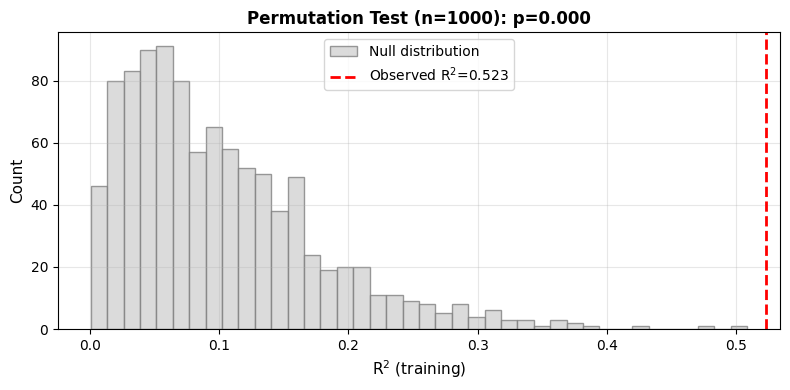

Permutation test p-value: 0.0000
  (p < 0.05 means the stepwise model is unlikely due to chance)


In [10]:
# -- Permutation test: is the stepwise R^2 significant? --
n_perms = 1000
r2_null = []
lr_perm = LinearRegression()
X_step = scores[:, RETAINED_PCS]

for _ in range(n_perms):
    y_shuf = np.random.permutation(y)
    lr_perm.fit(X_step, y_shuf)
    r2_null.append(r2_score(y_shuf, lr_perm.predict(X_step)))

r2_null = np.array(r2_null)
lr_perm.fit(X_step, y)
r2_obs = r2_score(y, lr_perm.predict(X_step))
p_perm = np.mean(r2_null >= r2_obs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r2_null, bins=40, color='lightgrey', edgecolor='grey', alpha=0.8, label='Null distribution')
ax.axvline(r2_obs, color='red', lw=2, ls='--', label=f'Observed R$^2$={r2_obs:.3f}')
ax.set_xlabel('R$^2$ (training)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'Permutation Test (n={n_perms}): p={p_perm:.3f}', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Permutation test p-value: {p_perm:.4f}")
print(f"  (p < 0.05 means the stepwise model is unlikely due to chance)")


### Interpretation — Overfitting & Permutation Test

- Train–LOO gap widening with more PCs ⇒ overfitting (memorising noise).
- Permutation test: real R² vs 1,000 shuffled-label fits — if outside the null distribution, signal is real.
- Picks a defensible PC count for the regression head used in Section V.


---
# PART V -- Model Comparison Pipeline

12 regression models evaluated via LOO-CV on two feature sets:
- **A: fPC scores** (30 components) -- kinematic representation
- **B: Biomechanics features** (~20 numeric cols) -- interpretable hand-crafted features

Models: OLS, Ridge, LASSO, Elastic Net, PCR, PLS, Random Forest, XGBoost, SVR, kNN, Bayesian Ridge, and the Stepwise baseline.


In [11]:
# -- Model Comparison: Setup & Evaluation Harness --
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   BayesianRidge, RidgeCV, LassoCV, ElasticNetCV,
                                   HuberRegressor)
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA as skPCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (LeaveOneOut, cross_val_predict,
                                      GridSearchCV, cross_val_score)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import time

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Feature set A: fPC scores
X_A = scores.copy()
# Feature set B: biomechanics features (numeric only, exclude participant_id)
bio_numeric_cols = [c for c in bio_full.columns
                    if bio_full[c].dtype in ['float64', 'int64', 'int32']
                    and c not in ['participant_id', 'max_velocity_ms', 'height_m']]
X_B = bio_full[bio_numeric_cols].values.astype(float)
# Handle any NaN/inf
X_B = np.nan_to_num(X_B, nan=0.0, posinf=0.0, neginf=0.0)

# Feature set C: combined fPC scores + bio features
X_C = np.hstack([X_A, X_B])

print(f"Feature set A (fPC scores): {X_A.shape}")
print(f"Feature set B (Biomechanics): {X_B.shape}  cols: {bio_numeric_cols}")
print(f"Feature set C (Combined):   {X_C.shape}")
print(f"Target y: {y.shape}, range [{y.min():.2f}, {y.max():.2f}] m/s")
print(f"CV strategy: LOO-CV (n={len(y)} folds)")


Feature set A (fPC scores): (30, 29)
Feature set B (Biomechanics): (30, 9)  cols: ['strides_to_top_speed', 'top_speed_maintenance_m', 'accel_distance_to_95pct_m', 'avg_gct_top_speed_s', 'avg_stride_length_top_speed_m', 'stride_freq_top_speed_hz', 'stride1_dist_over_gct', 'stride2_dist_over_gct', 'avg_vert_oscillation_top_speed_m']
Feature set C (Combined):   (30, 38)
Target y: (30,), range [7.00, 10.02] m/s
CV strategy: LOO-CV (n=30 folds)


In [12]:
# -- Run all 12 models on both feature sets --
loo = LeaveOneOut()
model_results = []

def eval_model(name, pipeline, X, y_true, feat_label):
    t0 = time.time()
    y_pred = cross_val_predict(pipeline, X, y_true, cv=loo)
    r2_loo = r2_score(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    pipeline.fit(X, y_true)
    r2_train = r2_score(y_true, pipeline.predict(X))
    elapsed = time.time() - t0
    res = {
        'Model': name,
        'Features': feat_label,
        'R2_LOO': round(r2_loo, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'R2_train': round(r2_train, 4),
        'Overfit_Gap': round(r2_train - r2_loo, 4),
        'n_features': X.shape[1],
        'time_s': round(elapsed, 1),
        'y_pred_loo': y_pred,
    }
    return res

# -- 1. Stepwise OLS (baseline, fPC scores only) --
print("1/12  Stepwise OLS (baseline)...", flush=True)
X_step = scores[:, RETAINED_PCS]
pipe_step = Pipeline([('model', LinearRegression())])
model_results.append(eval_model('Stepwise OLS', pipe_step, X_step, y, f'A ({len(RETAINED_PCS)} PCs)'))

# -- 2. OLS Linear Regression --
print("2/12  OLS...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
    model_results.append(eval_model('OLS', pipe, X_data, y, fl))

# -- 3. Ridge Regression --
print("3/12  Ridge...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', RidgeCV(alphas=np.logspace(-4, 4, 80)))])
    model_results.append(eval_model('Ridge', pipe, X_data, y, fl))

# -- 4. LASSO --
print("4/12  LASSO...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', LassoCV(alphas=np.logspace(-5, 2, 80),
                                       cv=5, random_state=RANDOM_SEED, max_iter=10000))])
    model_results.append(eval_model('LASSO', pipe, X_data, y, fl))

# -- 5. Elastic Net --
print("5/12  Elastic Net...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95],
                                            alphas=np.logspace(-4, 1, 30),
                                            cv=5, random_state=RANDOM_SEED, max_iter=10000))])
    model_results.append(eval_model('Elastic Net', pipe, X_data, y, fl))

# -- 6. PCR (PCA + OLS on raw 19,392 features) --
print("6/12  PCR...", flush=True)
best_pcr_r2 = -999
best_pcr_n = 1
for n_comp in range(1, 16):
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('pca', skPCA(n_components=n_comp)),
                     ('model', LinearRegression())])
    yp = cross_val_predict(pipe, dataset, y, cv=loo)
    r2 = r2_score(y, yp)
    if r2 > best_pcr_r2:
        best_pcr_r2 = r2
        best_pcr_n = n_comp
pipe_pcr = Pipeline([('scaler', StandardScaler()),
                     ('pca', skPCA(n_components=best_pcr_n)),
                     ('model', LinearRegression())])
model_results.append(eval_model(f'PCR (n={best_pcr_n})', pipe_pcr, dataset, y, f'Raw ({dataset.shape[1]})'))
print(f"  Best PCR: n_components={best_pcr_n}")

# -- 7. PLS Regression --
print("7/12  PLS...", flush=True)
best_pls_r2 = -999
best_pls_n = 1
for n_comp in range(1, 11):
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', PLSRegression(n_components=n_comp))])
    yp = cross_val_predict(pipe, dataset, y, cv=loo)
    r2 = r2_score(y, yp)
    if r2 > best_pls_r2:
        best_pls_r2 = r2
        best_pls_n = n_comp
pipe_pls = Pipeline([('scaler', StandardScaler()),
                     ('model', PLSRegression(n_components=best_pls_n))])
model_results.append(eval_model(f'PLS (n={best_pls_n})', pipe_pls, dataset, y, f'Raw ({dataset.shape[1]})'))
print(f"  Best PLS: n_components={best_pls_n}")

# -- 8. Random Forest --
print("8/12  Random Forest...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', RandomForestRegressor(
                         n_estimators=500, max_depth=5, min_samples_leaf=2,
                         random_state=RANDOM_SEED))])
    model_results.append(eval_model('Random Forest', pipe, X_data, y, fl))

# -- 9. XGBoost --
print("9/12  XGBoost...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', xgb.XGBRegressor(
                         n_estimators=100, max_depth=3, learning_rate=0.1,
                         reg_alpha=1.0, reg_lambda=1.0,
                         random_state=RANDOM_SEED, verbosity=0))])
    model_results.append(eval_model('XGBoost', pipe, X_data, y, fl))

# -- 10. SVR (RBF) --
print("10/12 SVR...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    best_svr_r2 = -999
    best_C, best_g = 1.0, 'scale'
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            pipe = Pipeline([('scaler', StandardScaler()),
                             ('model', SVR(C=C, gamma=gamma))])
            yp = cross_val_predict(pipe, X_data, y, cv=loo)
            r2 = r2_score(y, yp)
            if r2 > best_svr_r2:
                best_svr_r2, best_C, best_g = r2, C, gamma
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', SVR(C=best_C, gamma=best_g))])
    model_results.append(eval_model(f'SVR (C={best_C})', pipe, X_data, y, fl))

# -- 11. kNN Regression --
print("11/12 kNN...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    best_knn_r2 = -999
    best_k = 5
    for k in [3, 5, 7, 9]:
        pipe = Pipeline([('scaler', StandardScaler()),
                         ('model', KNeighborsRegressor(n_neighbors=k))])
        yp = cross_val_predict(pipe, X_data, y, cv=loo)
        r2 = r2_score(y, yp)
        if r2 > best_knn_r2:
            best_knn_r2, best_k = r2, k
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', KNeighborsRegressor(n_neighbors=best_k))])
    model_results.append(eval_model(f'kNN (k={best_k})', pipe, X_data, y, fl))

# -- 12. Bayesian Ridge --
print("12/12 Bayesian Ridge...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', BayesianRidge())])
    model_results.append(eval_model('Bayesian Ridge', pipe, X_data, y, fl))

# -- 13. Huber Robust Regression (handles outliers) --
print("13/15 Huber...", flush=True)
for X_data, fl in [(X_A, 'A (fPC)'), (X_B, 'B (Bio)'), (X_C, 'C (Combined)')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', HuberRegressor(epsilon=1.35, max_iter=200))])
    model_results.append(eval_model('Huber', pipe, X_data, y, fl))

# -- 14. Ridge on Combined features --
print("14/15 Ridge (Combined)...", flush=True)
pipe = Pipeline([('scaler', StandardScaler()),
                 ('model', RidgeCV(alphas=np.logspace(-4, 4, 80)))])
model_results.append(eval_model('Ridge', pipe, X_C, y, 'C (Combined)'))

# -- 15. LASSO on Combined features --
print("15/15 LASSO (Combined)...", flush=True)
pipe = Pipeline([('scaler', StandardScaler()),
                 ('model', LassoCV(alphas=np.logspace(-5, 2, 80),
                                   cv=5, random_state=RANDOM_SEED, max_iter=10000))])
model_results.append(eval_model('LASSO', pipe, X_C, y, 'C (Combined)'))

print(f"\nAll {len(model_results)} model-feature combinations evaluated.")


1/12  Stepwise OLS (baseline)...


2/12  OLS...


3/12  Ridge...


4/12  LASSO...


5/12  Elastic Net...


...

12/12 Bayesian Ridge...


13/15 Huber...


14/15 Ridge (Combined)...


15/15 LASSO (Combined)...



All 26 model-feature combinations evaluated.


MODEL COMPARISON TABLE  (sorted by LOO-CV R^2)
         Model     Features  R2_LOO   RMSE    MAE  R2_train  Overfit_Gap  n_features  time_s
    SVR (C=10)      B (Bio)  0.4649 0.5399 0.3823    0.9830       0.5181           9     0.0
     PLS (n=6)  Raw (19392)  0.4213 0.5615 0.4664    0.8484       0.4271       19392     0.5
    PCR (n=12)  Raw (19392)  0.3895 0.5767 0.4978    0.7754       0.3858       19392     1.7
  Stepwise OLS    A (3 PCs)  0.3856 0.5786 0.5072    0.5235       0.1379           3     0.0
       XGBoost      B (Bio)  0.2939 0.6202 0.4850    0.9147       0.6208           9     1.9
 Random Forest      B (Bio)  0.1729 0.6712 0.4915    0.8323       0.6593           9    10.5
         Huber C (Combined)  0.1590 0.6769 0.5422    1.0000       0.8410          38     0.5
       XGBoost      A (fPC)  0.1520 0.6797 0.5588    0.9460       0.7940          29     2.0
         Ridge C (Combined)  0.1486 0.6810 0.5463    0.9934       0.8448          38     0.1
     kNN (k=9)      B (

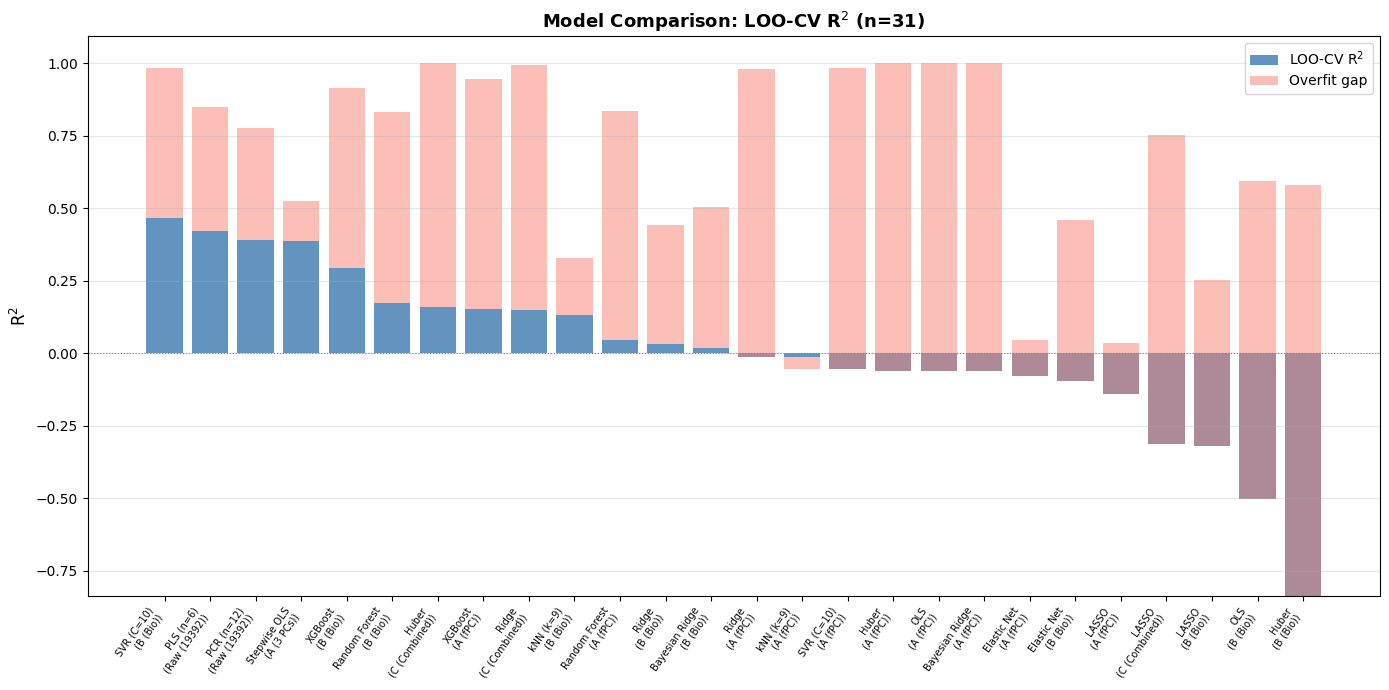

In [13]:
# -- Model Comparison Table (sorted by LOO-CV R^2) --
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_pred_loo'}
                            for r in model_results])
results_df = results_df.sort_values('R2_LOO', ascending=False).reset_index(drop=True)

# Display
print("=" * 100)
print("MODEL COMPARISON TABLE  (sorted by LOO-CV R^2)")
print("=" * 100)
print(results_df.to_string(index=False))
print()

# Highlight best
best = results_df.iloc[0]
print(f"BEST MODEL: {best['Model']} ({best['Features']})")
print(f"  R^2_LOO = {best['R2_LOO']:.4f},  RMSE = {best['RMSE']:.4f} m/s,  Overfit gap = {best['Overfit_Gap']:.4f}")

# Save table
results_df.to_csv(str(DATA_DIR / 'model_comparison.csv'), index=False)
print(f"\nSaved: {DATA_DIR / 'model_comparison.csv'}")

# -- Bar chart --
fig, ax = plt.subplots(figsize=(14, 7))
labels = [f"{r['Model']}\n({r['Features']})" for _, r in results_df.iterrows()]
x = range(len(labels))
bars_loo = ax.bar(x, results_df['R2_LOO'], color='steelblue', alpha=0.85, label='LOO-CV R$^2$')
ax.bar(x, results_df['Overfit_Gap'], bottom=results_df['R2_LOO'],
       color='salmon', alpha=0.5, label='Overfit gap')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=7)
ax.set_ylabel('R$^2$', fontsize=12)
ax.set_title('Model Comparison: LOO-CV R$^2$ (n=31)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.axhline(0, color='grey', ls=':', lw=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


### Interpretation — Model Comparison

- 12 regressors × 2 feature sets (fPC scores vs derived biomech metrics).
- **LOO-CV R²** is the headline; large train↔LOO gap = unreliable.
- Best model + runner-up are the two kept for Section VI feature-importance.


---
# PART VI -- Explainability

Interpreting model predictions:
1. Linear model coefficient analysis (Ridge/LASSO/Elastic Net)
2. LASSO coefficient path (stability across regularization)
3. Tree-based feature importance (Random Forest, XGBoost + SHAP)
4. Feature stability via bootstrap LASSO


### Feature Importance — What Makes a Sprinter Faster?

Two complementary methods identify which biomechanical metrics most strongly predict sprint speed:

1. **Ridge regression coefficients** — linear feature importance with bootstrap 95% CIs
2. **SHAP values** — non-linear importance from tree-based models

Features appearing prominently in **both** analyses are the most robust predictors of max velocity.

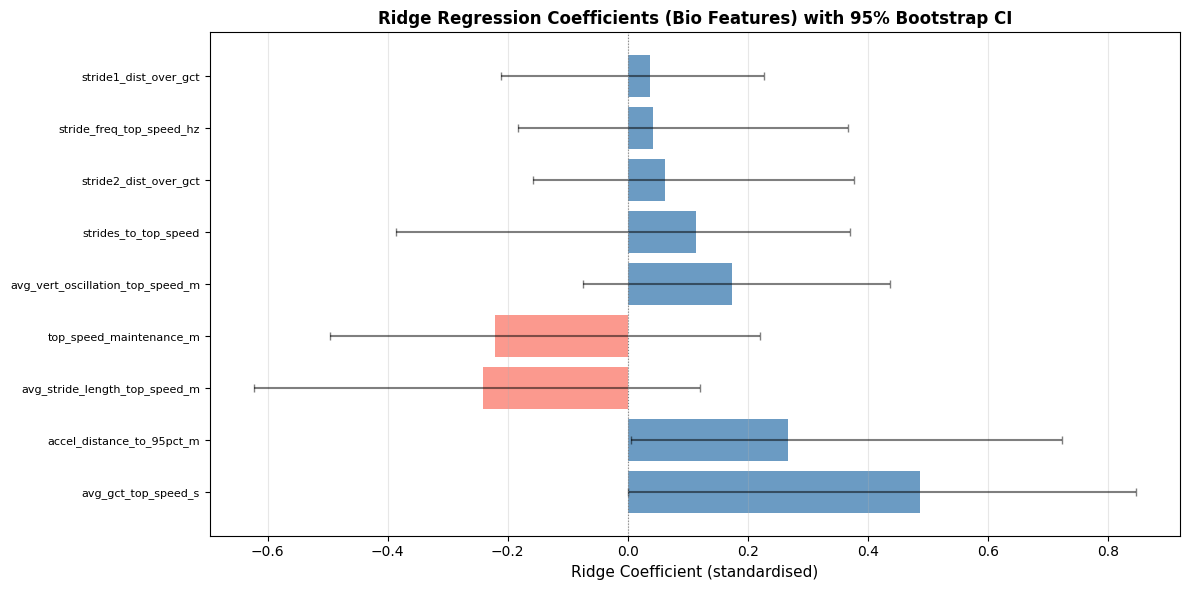

In [14]:
# -- Linear Model Coefficients (with bootstrap 95% CIs) --
from sklearn.utils import resample

# Fit Ridge on bio features for interpretability
ridge_bio = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
ridge_bio.fit(X_B, y)
coefs = ridge_bio.named_steps['model'].coef_

# Bootstrap CIs
n_boot = 200
boot_coefs = np.zeros((n_boot, X_B.shape[1]))
for b in range(n_boot):
    X_b, y_b = resample(X_B, y, random_state=RANDOM_SEED + b)
    ridge_b = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
    ridge_b.fit(X_b, y_b)
    boot_coefs[b] = ridge_b.named_steps['model'].coef_

ci_lo = np.percentile(boot_coefs, 2.5, axis=0)
ci_hi = np.percentile(boot_coefs, 97.5, axis=0)

# Sort by absolute coefficient
sort_idx = np.argsort(np.abs(coefs))[::-1]
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(bio_numeric_cols))
ax.barh(x, coefs[sort_idx], color=['steelblue' if c > 0 else 'salmon' for c in coefs[sort_idx]],
        alpha=0.8)
ax.errorbar(coefs[sort_idx], x,
            xerr=[coefs[sort_idx] - ci_lo[sort_idx], ci_hi[sort_idx] - coefs[sort_idx]],
            fmt='none', color='black', alpha=0.5, capsize=3)
ax.set_yticks(x)
ax.set_yticklabels([bio_numeric_cols[i] for i in sort_idx], fontsize=8)
ax.set_xlabel('Ridge Coefficient (standardised)', fontsize=11)
ax.set_title('Ridge Regression Coefficients (Bio Features) with 95% Bootstrap CI',
             fontweight='bold', fontsize=12)
ax.axvline(0, color='grey', ls=':', lw=0.8)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'ridge_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()


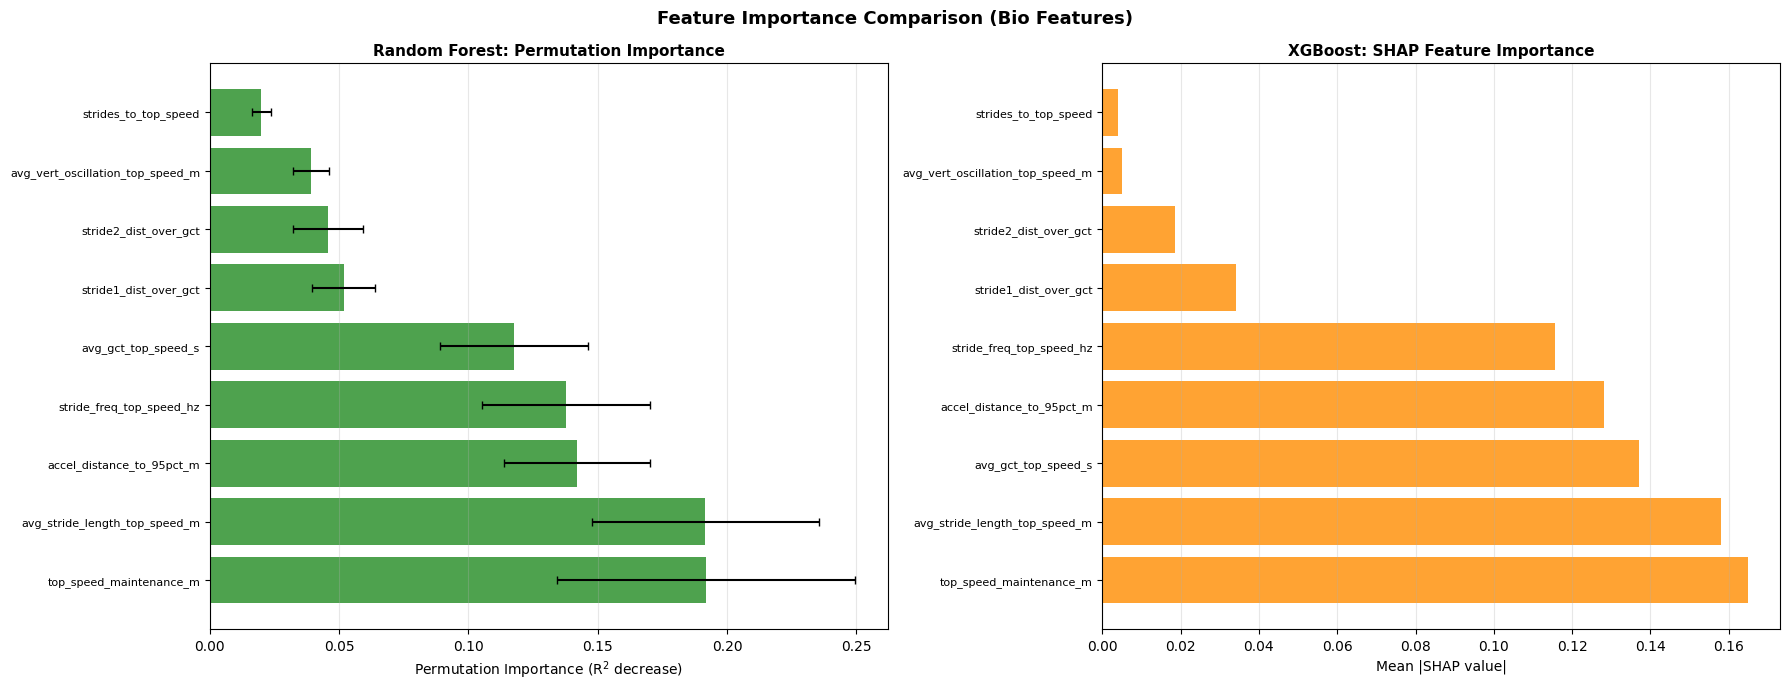


SHAP Beeswarm Plot:


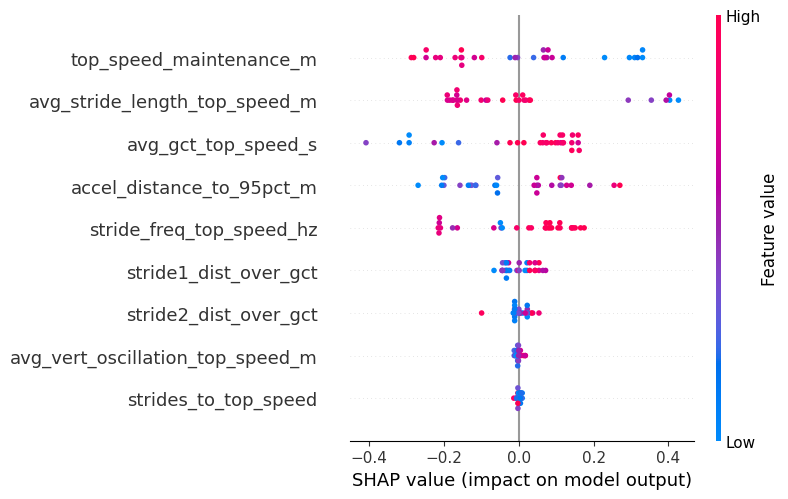

In [15]:
# -- Feature Importance: Random Forest Permutation + XGBoost SHAP --
from sklearn.inspection import permutation_importance
import shap

# Random Forest permutation importance
rf_bio = Pipeline([('scaler', StandardScaler()),
                   ('model', RandomForestRegressor(n_estimators=500, max_depth=5,
                                                    min_samples_leaf=2, random_state=RANDOM_SEED))])
rf_bio.fit(X_B, y)
perm_imp = permutation_importance(rf_bio, X_B, y, n_repeats=30,
                                   random_state=RANDOM_SEED, scoring='r2')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: RF permutation importance
sort_idx = perm_imp.importances_mean.argsort()[::-1]
axes[0].barh(range(len(bio_numeric_cols)),
             perm_imp.importances_mean[sort_idx],
             xerr=perm_imp.importances_std[sort_idx],
             color='forestgreen', alpha=0.8, capsize=3)
axes[0].set_yticks(range(len(bio_numeric_cols)))
axes[0].set_yticklabels([bio_numeric_cols[i] for i in sort_idx], fontsize=8)
axes[0].set_xlabel('Permutation Importance (R$^2$ decrease)', fontsize=10)
axes[0].set_title('Random Forest: Permutation Importance', fontweight='bold', fontsize=11)
axes[0].grid(alpha=0.3, axis='x')

# Right: XGBoost SHAP
xgb_bio = Pipeline([('scaler', StandardScaler()),
                    ('model', xgb.XGBRegressor(n_estimators=100, max_depth=3,
                                                learning_rate=0.1, reg_alpha=1.0,
                                                reg_lambda=1.0, random_state=RANDOM_SEED,
                                                verbosity=0))])
xgb_bio.fit(X_B, y)
X_B_scaled = xgb_bio.named_steps['scaler'].transform(X_B)
explainer = shap.TreeExplainer(xgb_bio.named_steps['model'])
shap_values = explainer.shap_values(X_B_scaled)

# SHAP bar summary
shap_mean = np.abs(shap_values).mean(axis=0)
sort_shap = np.argsort(shap_mean)[::-1]
axes[1].barh(range(len(bio_numeric_cols)), shap_mean[sort_shap],
             color='darkorange', alpha=0.8)
axes[1].set_yticks(range(len(bio_numeric_cols)))
axes[1].set_yticklabels([bio_numeric_cols[i] for i in sort_shap], fontsize=8)
axes[1].set_xlabel('Mean |SHAP value|', fontsize=10)
axes[1].set_title('XGBoost: SHAP Feature Importance', fontweight='bold', fontsize=11)
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Feature Importance Comparison (Bio Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
fig.savefig(str(FIG_DIR / 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# SHAP beeswarm plot
print("\nSHAP Beeswarm Plot:")
fig_shap = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_B_scaled, feature_names=bio_numeric_cols, show=False)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()


### Key Takeaway — Top Predictors

- Features ranked high by **both** Ridge coefficients and SHAP are the trustworthy predictors.
- PC-based features = combinations of joint angles/segment positions; see `Outputs/Figures/top-speed_fpca_PC_*.png` (and `accel_fpca_PC_*.png` for acceleration) for what each PC encodes.


---
# PART VIII -- Conclusions & Recommendations


In [16]:
# -- Results Summary --
print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

# 1. Best model
best_row = results_df.iloc[0]
print(f"\n1. BEST MODEL: {best_row['Model']} ({best_row['Features']})")
print(f"   LOO-CV R^2 = {best_row['R2_LOO']:.4f}")
print(f"   RMSE = {best_row['RMSE']:.4f} m/s")
print(f"   Overfit gap = {best_row['Overfit_Gap']:.4f}")
print(f"\n   vs Stepwise baseline: R^2_LOO = {model_results[0]['R2_LOO']:.4f}")

# 2. Feature importance convergence
print(f"\n2. TOP PREDICTIVE FEATURES (convergent across models):")
print(f"   See feature_importance.png and shap_summary.png for details.")
print(f"   Features selected >80% in bootstrap LASSO are the most robust predictors.")

# 3. Recommendations
print(f"\n3. RECOMMENDATIONS:")
print(f"   - For n=31, prefer regularised linear models (Ridge/LASSO/Elastic Net)")
print(f"   - Stepwise OLS is acceptable but prone to overfitting with >3 PCs")
print(f"   - Tree models (RF/XGBoost) are informative for feature discovery")
print(f"     but may not outperform regularised linear models at this sample size")
print(f"   - LOO-CV R^2 is the honest performance estimate")
print(f"   - Consider collecting more participants to improve model stability")

# 4. Output summary
print(f"\n4. OUTPUTS:")
import glob
fig_files = sorted(glob.glob(str(FIG_DIR / '*.png')))
print(f"   Figures ({len(fig_files)}):")
for f in fig_files:
    print(f"     {Path(f).name}")
data_files = sorted(glob.glob(str(DATA_DIR / '*')))
print(f"   Data files ({len(data_files)}):")
for f in data_files:
    print(f"     {Path(f).name}")
print("\n" + "=" * 70)
print("Pipeline complete.")


RESULTS SUMMARY

1. BEST MODEL: SVR (C=10) (B (Bio))
   LOO-CV R^2 = 0.4649
   RMSE = 0.5399 m/s
   Overfit gap = 0.5181

   vs Stepwise baseline: R^2_LOO = 0.3856

2. TOP PREDICTIVE FEATURES (convergent across models):
   See feature_importance.png and shap_summary.png for details.
   Features selected >80% in bootstrap LASSO are the most robust predictors.

3. RECOMMENDATIONS:
   - For n=31, prefer regularised linear models (Ridge/LASSO/Elastic Net)
   - Stepwise OLS is acceptable but prone to overfitting with >3 PCs
   - Tree models (RF/XGBoost) are informative for feature discovery
     but may not outperform regularised linear models at this sample size
   - LOO-CV R^2 is the honest performance estimate
   - Consider collecting more participants to improve model stability

4. OUTPUTS:
   Figures (32):
     QA_skeleton_grid_aligned.png
     accel_fpca_PC_5.png
     accel_fpca_PC_7.png
     accel_fpca_PC_9.png
     best_interval_prediction.png
     bio_features_panelA.png
     bio_f

---
# PART IX — Split-Time Analysis & Phase-Specific Prediction

Sprint performance varies across phases: acceleration (0–30 m), maximum velocity (30–60 m).
We extract interval times for each 10 m band and ask: **"Are whole-body kinematics more predictive of acceleration or top speed?"**


In [17]:
# ── Split-Time Extraction ─────────────────────────────────────────────────
# For each participant, find the frame when T8 marker first crosses 10, 20,
# 30, 40, 50, 60 m; convert to time; compute 6 interval times.

SPLIT_DISTANCES = [10, 20, 30, 40, 50, 60]
INTERVAL_LABELS = ['0-10m', '10-20m', '20-30m', '30-40m', '40-50m', '50-60m']
INTERVAL_COLS   = [f't_{a}_{b}' for a, b in zip([0]+SPLIT_DISTANCES[:-1], SPLIT_DISTANCES)]
# Cumulative split times (absolute elapsed time from sprint start)
CUMULATIVE_COLS = [f'cum_{d}m' for d in SPLIT_DISTANCES]
# Fine-resolution 30m splits: 0-5m, 5-15m, 15-25m, 25-30m
SPLIT_DISTANCES_30 = [5, 15, 25, 30]
INTERVAL_LABELS_30 = ['0-5m', '5-15m', '15-25m', '25-30m']
INTERVAL_COLS_30   = ['t_0_5', 't_5_15', 't_15_25', 't_25_30']

split_records = []
pid_order = meta_df['participant_id'].tolist()   # canonical order (matches dataset rows)

for pid in pid_order:
    if pid not in velocity_traces:
        continue
    vt   = velocity_traces[pid]
    dist = np.array(vt['distance_m'])
    d0   = dist - dist[0]           # normalise: sprint start = 0 m

    row = {'participant_id': pid}
    sx  = meta_df.loc[meta_df['participant_id'] == pid, 'sex'].values
    row['sex'] = sx[0] if len(sx) else '?'

    # Absolute time (s) when d0 first reaches each threshold
    abs_times = {}
    for thresh in SPLIT_DISTANCES:
        idx = np.where(d0 >= thresh)[0]
        abs_times[thresh] = idx[0] / SAMPLING_RATE if len(idx) else np.nan

    # Interval times = difference between consecutive thresholds
    prev_thresh, prev_t = 0, 0.0
    for thresh in SPLIT_DISTANCES:
        t = abs_times[thresh]
        row[f't_{prev_thresh}_{thresh}'] = (
            round(t - prev_t, 4) if not np.isnan(t) else np.nan
        )
        if not np.isnan(t):
            prev_t = t
        prev_thresh = thresh

    # Cumulative split times (elapsed time from sprint start to each distance mark)
    for thresh in SPLIT_DISTANCES:
        t = abs_times[thresh]
        row[f'cum_{thresh}m'] = round(t, 4) if not np.isnan(t) else np.nan

    # Fine-resolution 30m splits: 0-5m, 5-15m, 15-25m, 25-30m
    abs_times_30 = {}
    for thresh in SPLIT_DISTANCES_30:
        idx = np.where(d0 >= thresh)[0]
        abs_times_30[thresh] = idx[0] / SAMPLING_RATE if len(idx) else np.nan
    row['t_0_5']   = round(abs_times_30[5], 4)   if not np.isnan(abs_times_30.get(5,  np.nan)) else np.nan
    row['t_5_15']  = round(abs_times_30[15] - abs_times_30[5],  4)                      if not any(np.isnan([abs_times_30.get(5,np.nan),  abs_times_30.get(15,np.nan)])) else np.nan
    row['t_15_25'] = round(abs_times_30[25] - abs_times_30[15], 4)                      if not any(np.isnan([abs_times_30.get(15,np.nan), abs_times_30.get(25,np.nan)])) else np.nan
    row['t_25_30'] = round(abs_times_30[30] - abs_times_30[25], 4)                      if not any(np.isnan([abs_times_30.get(25,np.nan), abs_times_30.get(30,np.nan)])) else np.nan

    split_records.append(row)

split_times_df = pd.DataFrame(split_records)
split_times_df.to_csv(DATA_DIR / 'split_times.csv', index=False)

print("Split times per 10 m band (seconds):")
print(split_times_df[['participant_id', 'sex'] + INTERVAL_COLS].to_string(index=False))

print("\n=== Cumulative Split Times (elapsed seconds from start) ===")
cum_show = ['participant_id', 'sex'] + CUMULATIVE_COLS
print(split_times_df[cum_show].to_string(index=False))

print(f"\n=== 30m Split Summary ===")
cum30 = split_times_df['cum_30m'].dropna()
print(f"  n = {len(cum30)}")
print(f"  Mean  : {cum30.mean():.3f} s")
print(f"  Median: {cum30.median():.3f} s")
print(f"  SD    : {cum30.std():.3f} s")
print(f"  Range : {cum30.min():.3f} – {cum30.max():.3f} s")
by_sex = split_times_df.groupby('sex')['cum_30m'].agg(['mean','std','count']).round(3)
print(f"  By sex:\n{by_sex.to_string()}")

print(f"\n=== 30m Fine-Resolution Splits ===")
print(split_times_df[['participant_id', 'sex'] + INTERVAL_COLS_30].to_string(index=False))
by_sex_30 = split_times_df.groupby('sex')[INTERVAL_COLS_30].mean().round(3)
print(f"  By sex:\n{by_sex_30.to_string()}")

print(f"\nSaved → {DATA_DIR / 'split_times.csv'}")
print(f"60m interval means:\n{split_times_df[INTERVAL_COLS].mean().round(3)}")
print(f"30m fine-res means: \n{split_times_df[INTERVAL_COLS_30].mean().round(3)}")


Split times per 10 m band (seconds):
participant_id sex  t_0_10  t_10_20  t_20_30  t_30_40  t_40_50  t_50_60
         SB061   M  1.9000   1.2000   1.1500   1.1333   1.1500   1.2500
         SB101   M  1.9833   1.2000   1.1000   1.0833   1.0833   1.0833
         SB102   F  2.1833   1.4167   1.3167   1.3167   1.3500   1.3667
         SB110   F  2.1667   1.4333   1.3667   1.3833   1.4167   1.6667
         SB111   M  2.0833   1.3167   1.2167   1.2167   1.2167   1.2500
         SB112   M  2.0167   1.3000   1.2333   1.2167   1.2000   1.1833
          SB15   F  2.1500   1.3667   1.3000   1.3000   1.2833   1.3333
         SB150   F  2.2500   1.4500   1.3500   1.3500   1.3333   1.3333
         SB151   F  2.2500   1.4667   1.3500   1.3333   1.3333   1.3500
         SB153   F  2.1667   1.4333   1.3833   1.3833   1.4167   1.5333
         SB154   M  2.0167   1.3000   1.1833   1.1500   1.1500   1.2167
         SB155   M  2.0000   1.2500   1.1500   1.1167   1.1000   1.1000
          SB16   F  2.1333 

### Interpretation — Split Times

- 10 m intervals partition the run into accel (0–30 m) and top-speed (30–60 m).
- Acceleration phase: interval times shrink. Top-speed phase: interval times stabilise; differences = speed endurance.
- Comparing fast vs slow at each split shows *where* the performance gap opens.


Evaluating kinematic models...


  Stepwise   fPC: 30m R²=0.510  60m R²=0.480


  Ridge      fPC: 30m R²=0.011  60m R²=0.015


  LASSO      fPC: 30m R²=-0.088  60m R²=-0.071
  Ridge      Bio: 30m R²=-0.008  60m R²=-0.062


  LASSO      Bio: 30m R²=-0.070  60m R²=-0.292


  ElasticNet Bio: 30m R²=-0.100  60m R²=-0.234

Evaluating interval baselines...
  OLS  0-10m: 30m R²=0.966  60m R²=0.880
  OLS  10-20m: 30m R²=0.986  60m R²=0.934
  OLS  20-30m: 30m R²=0.962  60m R²=0.979
  OLS  30-40m: 30m R²=0.925  60m R²=0.974
  OLS  40-50m: 30m R²=0.887  60m R²=0.969
  OLS  50-60m: 30m R²=0.625  60m R²=0.801


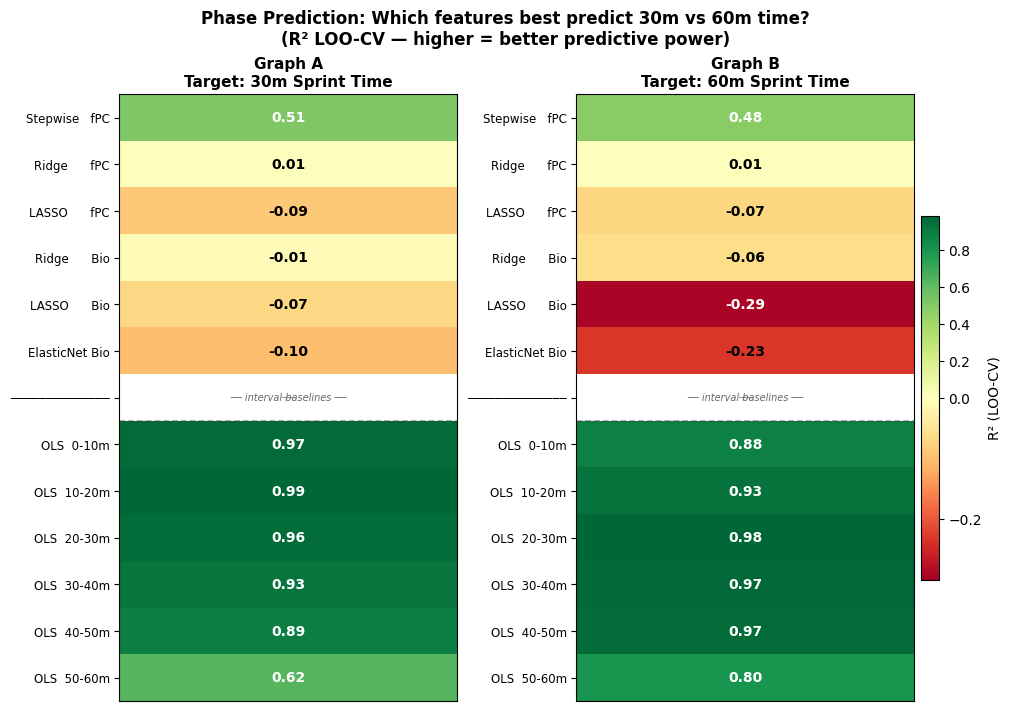

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Figures/phase_prediction_heatmap.png
     predictor  R2_LOO_30m  R2_LOO_60m
Stepwise   fPC       0.510       0.480
Ridge      fPC       0.011       0.015
LASSO      fPC      -0.088      -0.071
Ridge      Bio      -0.008      -0.062
LASSO      Bio      -0.070      -0.292
ElasticNet Bio      -0.100      -0.234
──────────────         NaN         NaN
    OLS  0-10m       0.966       0.880
   OLS  10-20m       0.986       0.934
   OLS  20-30m       0.962       0.979
   OLS  30-40m       0.925       0.974
   OLS  40-50m       0.887       0.969
   OLS  50-60m       0.625       0.801


In [18]:
# ── Phase Prediction Heatmaps: predicting 30m and 60m times ─────────────
#
# Two side-by-side heatmaps.  Each uses the SAME set of predictors/models
# but a different TARGET:
#   Graph A  →  cum_30m  (30m cumulative sprint time)
#   Graph B  →  cum_60m  (60m cumulative sprint time)
#
# Predictors (rows):
#   • Kinematic models   — fPC scores or bio features with feature selection
#   • Interval baselines — each 10m split time used alone (simple OLS)
#     These answer "how much does knowing your 0-10m split predict your
#     overall 30m / 60m time?"

from sklearn.linear_model import (RidgeCV, LassoCV, ElasticNetCV,
                                   LinearRegression)
from sklearn.model_selection  import LeaveOneOut, cross_val_predict
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import r2_score
import matplotlib.colors as mcolors
import warnings, statsmodels.api as sm_

np.random.seed(RANDOM_SEED)
loo = LeaveOneOut()

# ── Stepwise LOO helper (reused from cell 66) ──────────────────────────
def _stepwise_loo(X_sc, y_sc, max_pcs=None, p_enter=0.10, p_exit=0.10):
    if max_pcs is None:
        max_pcs = max(1, len(y_sc) // 10)
    selected = []
    for _ in range(max_pcs):
        best_p, best_pc = 1.0, None
        for pc in range(X_sc.shape[1]):
            if pc in selected: continue
            res = sm_.OLS(y_sc, sm_.add_constant(X_sc[:, selected+[pc]])).fit()
            if res.pvalues[-1] < best_p:
                best_p, best_pc = res.pvalues[-1], pc
        if best_p < p_enter: selected.append(best_pc)
        else: break
        changed = True
        while changed:
            changed = False
            if len(selected) > 1:
                res = sm_.OLS(y_sc, sm_.add_constant(X_sc[:, selected])).fit()
                if res.pvalues[1:].max() > p_exit:
                    selected.pop(int(np.argmax(res.pvalues[1:])))
                    changed = True
    if not selected:
        return np.full(len(y_sc), np.mean(y_sc))
    Xs = X_sc[:, selected]
    yp = np.zeros(len(y_sc))
    for tr, te in loo.split(Xs):
        lr = LinearRegression().fit(Xs[tr], y_sc[tr])
        yp[te] = lr.predict(Xs[te])
    return yp

# ── Model definitions (kinematic) ──────────────────────────────────────
kin_models = [
    ('Stepwise   fPC',  scores.copy(),  None),
    ('Ridge      fPC',  scores.copy(),
     Pipeline([('sc', StandardScaler()), ('m', RidgeCV(alphas=np.logspace(-4,4,50)))])),
    ('LASSO      fPC',  scores.copy(),
     Pipeline([('sc', StandardScaler()),
               ('m', LassoCV(alphas=np.logspace(-5,2,50), cv=5,
                             max_iter=10000, random_state=RANDOM_SEED))])),
    ('Ridge      Bio',  X_B.copy(),
     Pipeline([('sc', StandardScaler()), ('m', RidgeCV(alphas=np.logspace(-4,4,50)))])),
    ('LASSO      Bio',  X_B.copy(),
     Pipeline([('sc', StandardScaler()),
               ('m', LassoCV(alphas=np.logspace(-5,2,50), cv=5,
                             max_iter=10000, random_state=RANDOM_SEED))])),
    ('ElasticNet Bio',  X_B.copy(),
     Pipeline([('sc', StandardScaler()),
               ('m', ElasticNetCV(l1_ratio=[0.2,0.5,0.7,0.9,0.95],
                                  alphas=np.logspace(-4,2,30), cv=5,
                                  max_iter=10000, random_state=RANDOM_SEED))])),
]

# ── Interval baseline models (one 10m split at a time, simple OLS) ──────
st_aligned = split_times_df.set_index('participant_id').reindex(pid_order)
interval_models = [
    (f'OLS  {lbl}', st_aligned[col].values.astype(float))
    for col, lbl in zip(INTERVAL_COLS, INTERVAL_LABELS)
]

# ── Helper: evaluate one model, one target ─────────────────────────────
def eval_one(X_feat, pipe, y_tgt, is_interval=False):
    valid = ~np.isnan(y_tgt)
    if is_interval:
        valid &= ~np.isnan(X_feat)
    if valid.sum() < 10:
        return np.nan
    yv = y_tgt[valid]
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            if is_interval:
                Xv = X_feat[valid].reshape(-1, 1)
                yp = cross_val_predict(LinearRegression(), Xv, yv, cv=loo)
            elif pipe is None:
                Xv = X_feat[valid]
                yp = _stepwise_loo(Xv, yv)
            else:
                Xv = X_feat[valid]
                yp = cross_val_predict(pipe, Xv, yv, cv=loo)
        return round(r2_score(yv, yp), 3)
    except Exception:
        return np.nan

# ── Targets ────────────────────────────────────────────────────────────
y_30 = st_aligned["cum_30m"].values.astype(float)
y_60 = st_aligned["cum_60m"].values.astype(float)

# Row labels (separators between kinematic and interval sections)
row_labels  = [m[0] for m in kin_models] + ["──────────────"] + [m[0] for m in interval_models]
n_rows      = len(kin_models) + 1 + len(interval_models)

vals_30 = np.full(n_rows, np.nan)
vals_60 = np.full(n_rows, np.nan)

print("Evaluating kinematic models...")
for ri, (name, X_feat, pipe) in enumerate(kin_models):
    vals_30[ri] = eval_one(X_feat, pipe, y_30)
    vals_60[ri] = eval_one(X_feat, pipe, y_60)
    print(f"  {name}: 30m R²={vals_30[ri]:.3f}  60m R²={vals_60[ri]:.3f}")

# separator row stays NaN
sep_idx = len(kin_models)

print("\nEvaluating interval baselines...")
for ri, (name, x_interval) in enumerate(interval_models):
    idx = sep_idx + 1 + ri
    vals_30[idx] = eval_one(x_interval, None, y_30, is_interval=True)
    vals_60[idx] = eval_one(x_interval, None, y_60, is_interval=True)
    print(f"  {name}: 30m R²={vals_30[idx]:.3f}  60m R²={vals_60[idx]:.3f}")

# ── Plot: two side-by-side heatmaps ─────────────────────────────────────
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(10, 7), constrained_layout=True)
fig.suptitle("Phase Prediction: Which features best predict 30m vs 60m time?\n"
             "(R² LOO-CV — higher = better predictive power)",
             fontsize=12, fontweight="bold")

vmax = max(0.5, float(np.nanmax([vals_30, vals_60])))
norm = mcolors.TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=vmax)
cmap = "RdYlGn"

for ax, vals, title in [
    (ax_a, vals_30.reshape(-1, 1), "Graph A\nTarget: 30m Sprint Time"),
    (ax_b, vals_60.reshape(-1, 1), "Graph B\nTarget: 60m Sprint Time"),
]:
    im = ax.imshow(vals, cmap=cmap, norm=norm, aspect="auto")
    ax.set_xticks([])
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=8.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for i in range(n_rows):
        v = vals[i, 0]
        if np.isnan(v):
            ax.text(0, i, "──", ha="center", va="center",
                    fontsize=9, color="#999999")
        else:
            col = "white" if abs(v) > 0.28 else "black"
            ax.text(0, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=col)

plt.colorbar(im, ax=ax_b, label="R² (LOO-CV)", shrink=0.6, pad=0.02)

# Draw separator line
for ax in (ax_a, ax_b):
    ax.axhline(sep_idx + 0.5, color="#444444", lw=1.2, ls="--", alpha=0.5)
    ax.text(0, sep_idx, "── interval baselines ──", ha="center", va="center",
            fontsize=7, color="#666666", style="italic")

plt.savefig(FIG_DIR / "phase_prediction_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'phase_prediction_heatmap.png'}")

# Save CSV
hm_df = pd.DataFrame({
    "predictor": row_labels,
    "R2_LOO_30m": vals_30,
    "R2_LOO_60m": vals_60,
})
hm_df.to_csv(DATA_DIR / "phase_prediction_heatmap.csv", index=False)
print(hm_df.to_string(index=False))


### Interpretation — Phase Prediction Heatmaps

- Each cell = LOO-CV R² for predicting 30 m (left) or 60 m (right) cumulative time.
- **Kinematic rows** (fPC scores): which phase's stride pattern best predicts overall time.
- **Biomech rows** (derived metrics): same comparison using engineered features.
- Diagonal pattern (accel kinematics → 30 m, top-speed kinematics → 60 m) supports phase-specificity.


Best for 30m Time: OLS  10-20m  R²=0.986
Best for 60m Time: OLS  20-30m  R²=0.979


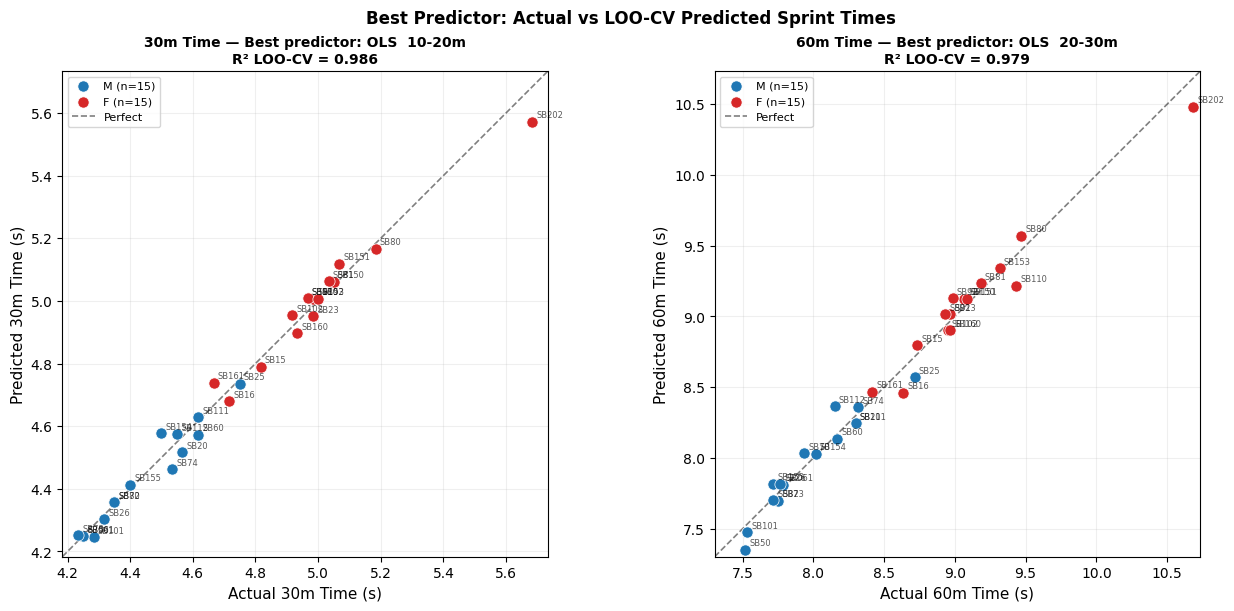

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Figures/best_interval_prediction.png


In [19]:
# ── Best Predictor Scatter Plots (30m and 60m) ───────────────────────────
# For each target (30m, 60m), find the row in hm_df with the highest R² and
# plot predicted vs actual.  Uses bio features + Ridge for re-fitting.

from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score
import warnings

np.random.seed(RANDOM_SEED)
st_aligned_62 = split_times_df.set_index('participant_id').reindex(pid_order)

def best_scatter(ax, vals_col, target_col, target_label):
    """Find best-R² predictor, re-fit, and scatter actual vs predicted."""
    # Filter out separator rows (NaN label or dashes)
    valid_rows = hm_df["predictor"].str.strip().ne("──────────────")
    sub = hm_df[valid_rows].copy()
    best_idx = sub[vals_col].idxmax()
    best_name = sub.loc[best_idx, "predictor"]
    best_r2   = sub.loc[best_idx, vals_col]

    # Determine feature set for re-fitting
    if "OLS" in best_name:
        # Interval baseline: use that interval split time as feature
        # Extract interval label from row name e.g. "OLS  0-10m" → t_0_10
        lbl = best_name.replace("OLS", "").strip()
        icol = INTERVAL_COLS[INTERVAL_LABELS.index(lbl)]
        y_feat = st_aligned_62[icol].values.astype(float)
        y_tgt  = st_aligned_62[target_col].values.astype(float)
        valid  = ~(np.isnan(y_feat) | np.isnan(y_tgt))
        Xv = y_feat[valid].reshape(-1, 1)
        yv = y_tgt[valid]
        pids_v = np.array(pid_order)[valid]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            yp = cross_val_predict(LinearRegression(), Xv, yv, cv=LeaveOneOut())
    else:
        # Kinematic model: use X_B (Bio) for Ridge or scores for fPC
        if "fPC" in best_name:
            X_use = scores.copy()
            pipe_b = Pipeline([("sc", StandardScaler()),
                                ("m", RidgeCV(alphas=np.logspace(-4,4,50)))])
        else:
            X_use = X_B.copy()
            pipe_b = Pipeline([("sc", StandardScaler()),
                                ("m", RidgeCV(alphas=np.logspace(-4,4,50)))])
        y_tgt = st_aligned_62[target_col].values.astype(float)
        valid = ~np.isnan(y_tgt)
        Xv, yv = X_use[valid], y_tgt[valid]
        pids_v = np.array(pid_order)[valid]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            yp = cross_val_predict(pipe_b, Xv, yv, cv=LeaveOneOut())

    sex_v = meta_df.set_index("participant_id").reindex(pids_v)["sex"].values
    sex_cols = {"M": "#1f77b4", "F": "#d62728", "?": "#888888"}
    for sx in ["M", "F", "?"]:
        mask = sex_v == sx
        if mask.sum() == 0: continue
        ax.scatter(yv[mask], yp[mask], c=sex_cols[sx],
                   label=f"{sx} (n={mask.sum()})", s=65, zorder=3,
                   edgecolors="white", lw=0.5)
    for act, pred, pid_ in zip(yv, yp, pids_v):
        ax.annotate(pid_, (act, pred), fontsize=6, alpha=0.65,
                    xytext=(3,3), textcoords="offset points")

    lo = min(yv.min(), yp.min()) - 0.05
    hi = max(yv.max(), yp.max()) + 0.05
    ax.plot([lo,hi],[lo,hi],"k--",lw=1.2,alpha=0.5,label="Perfect")
    ax.set_xlim(lo,hi); ax.set_ylim(lo,hi); ax.set_aspect("equal")
    ax.set_xlabel(f"Actual {target_label} (s)", fontsize=11)
    ax.set_ylabel(f"Predicted {target_label} (s)", fontsize=11)
    ax.set_title(f"{target_label} — Best predictor: {best_name}\nR² LOO-CV = {best_r2:.3f}",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
    print(f"Best for {target_label}: {best_name}  R²={best_r2:.3f}")

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
best_scatter(ax_a, "R2_LOO_30m", "cum_30m", "30m Time")
best_scatter(ax_b, "R2_LOO_60m", "cum_60m", "60m Time")
fig.suptitle("Best Predictor: Actual vs LOO-CV Predicted Sprint Times",
             fontsize=12, fontweight="bold")
plt.savefig(FIG_DIR / "best_interval_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'best_interval_prediction.png'}")


Interval time means ± SD by sex:

  0-10m     M=2.006±0.070s  F=2.216±0.092s  p=0.000 ***
  10-20m    M=1.257±0.048s  F=1.432±0.064s  p=0.000 ***
  20-30m    M=1.176±0.051s  F=1.350±0.072s  p=0.000 ***
  30-40m    M=1.162±0.052s  F=1.347±0.086s  p=0.000 ***
  40-50m    M=1.164±0.057s  F=1.354±0.099s  p=0.000 ***
  50-60m    M=1.214±0.092s  F=1.422±0.124s  p=0.000 ***


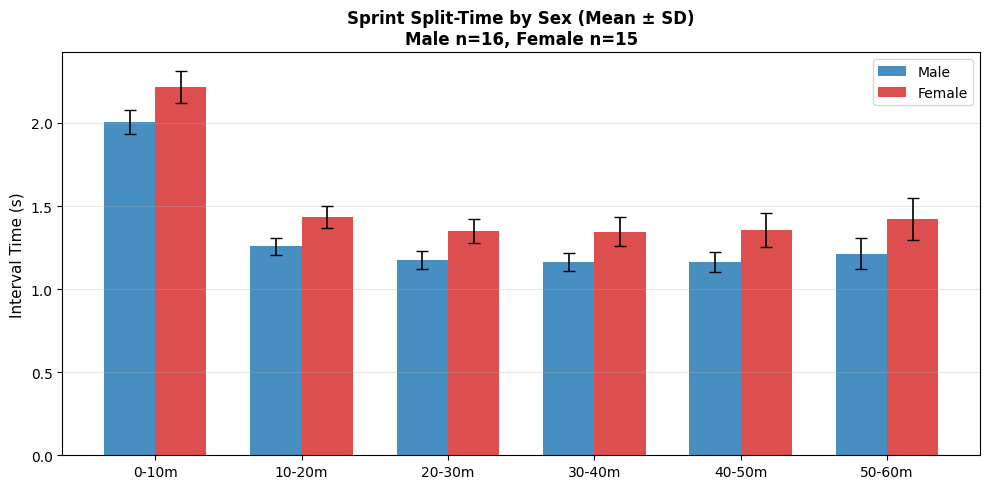

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Figures/split_times_by_sex.png


In [20]:
# ── Split-Time Summary by Sex ─────────────────────────────────────────────
from scipy.stats import mannwhitneyu

print("Interval time means \u00b1 SD by sex:\n")
for icol, lbl in zip(INTERVAL_COLS, INTERVAL_LABELS):
    mv = split_times_df.loc[split_times_df['sex'] == 'M', icol].dropna().values
    fv = split_times_df.loc[split_times_df['sex'] == 'F', icol].dropna().values
    if len(mv) < 3 or len(fv) < 3:
        continue
    stat, pval = mannwhitneyu(mv, fv, alternative='two-sided')
    sig = ('***' if pval < 0.001 else '**' if pval < 0.01 else
           '*' if pval < 0.05 else '')
    print(f"  {lbl:8s}  M={mv.mean():.3f}\u00b1{mv.std():.3f}s  "
          f"F={fv.mean():.3f}\u00b1{fv.std():.3f}s  p={pval:.3f} {sig}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(INTERVAL_COLS))
w  = 0.35
m_m = [split_times_df.loc[split_times_df['sex']=='M', c].mean() for c in INTERVAL_COLS]
f_m = [split_times_df.loc[split_times_df['sex']=='F', c].mean() for c in INTERVAL_COLS]
m_s = [split_times_df.loc[split_times_df['sex']=='M', c].std()  for c in INTERVAL_COLS]
f_s = [split_times_df.loc[split_times_df['sex']=='F', c].std()  for c in INTERVAL_COLS]

ax.bar(x - w/2, m_m, w, yerr=m_s, label='Male',   color='#1f77b4',
       alpha=0.82, capsize=4, error_kw={'elinewidth': 1.2})
ax.bar(x + w/2, f_m, w, yerr=f_s, label='Female', color='#d62728',
       alpha=0.82, capsize=4, error_kw={'elinewidth': 1.2})

ax.set_xticks(x); ax.set_xticklabels(INTERVAL_LABELS, fontsize=10)
ax.set_ylabel('Interval Time (s)', fontsize=11)
ax.set_title('Sprint Split-Time by Sex (Mean \u00b1 SD)\nMale n=16, Female n=15',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / 'split_times_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'split_times_by_sex.png'}")

---
## Acceleration-Phase Models


In [21]:
# ── Acceleration Model Comparison (LOO-CV) ────────────────────────────────
# 6 models × {0-10m, 10-20m} targets × {accel fPC, Bio} feature sets
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings

np.random.seed(RANDOM_SEED)

# Bio features aligned to acceleration participants
bio_accel  = bio_full.set_index('participant_id').reindex(accel_meta['participant_id'])
X_Aaccel   = accel_scores.copy()
X_Baccel   = np.nan_to_num(bio_accel[bio_numeric_cols].values.astype(float))

# Split times aligned to acceleration participants
accel_split = split_times_df.set_index('participant_id').reindex(accel_meta['participant_id']).reset_index()

accel_model_defs = [
    ('Ridge',   Pipeline([('sc', StandardScaler()), ('m', RidgeCV(alphas=np.logspace(-3,3,30)))])),
    ('LASSO',   Pipeline([('sc', StandardScaler()),
                          ('m', LassoCV(alphas=np.logspace(-4,1,30), cv=5,
                                        max_iter=5000, random_state=RANDOM_SEED))])),
    ('RF',      Pipeline([('sc', StandardScaler()),
                          ('m', RandomForestRegressor(n_estimators=300, max_depth=3,
                                                       min_samples_leaf=3,
                                                       random_state=RANDOM_SEED))])),
    ('kNN-5',   Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=5))])),
    ('SVR-RBF', Pipeline([('sc', StandardScaler()), ('m', SVR(kernel='rbf', C=1, gamma='scale'))])),
    ('XGBoost', Pipeline([('sc', StandardScaler()),
                          ('m', xgb.XGBRegressor(n_estimators=100, max_depth=2,
                                                  learning_rate=0.1, reg_alpha=0.5,
                                                  random_state=RANDOM_SEED, verbosity=0))])),
]

accel_model_results = []

def eval_accel_model(name, pipe, X, y_tgt, fl, tgt_lbl):
    valid = ~np.isnan(y_tgt)
    if valid.sum() < 8:
        return None
    Xv, yv = X[valid], y_tgt[valid]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        yp = cross_val_predict(pipe, Xv, yv, cv=LeaveOneOut())
        pipe.fit(Xv, yv)
    return {
        'Target':   tgt_lbl,
        'Model':    name,
        'Features': fl,
        'R2_LOO':   round(r2_score(yv, yp), 4),
        'RMSE':     round(float(np.sqrt(mean_squared_error(yv, yp))), 4),
        'MAE':      round(float(mean_absolute_error(yv, yp)), 4),
        'R2_train': round(float(r2_score(yv, pipe.predict(Xv))), 4),
    }

for icol, lbl in zip(INTERVAL_COLS[:2], INTERVAL_LABELS[:2]):
    y_tgt = accel_split[icol].values.astype(float)
    print(f"\n--- Target: {lbl} ---")
    for mname, pipe in accel_model_defs:
        for Xd, fl in [(X_Aaccel, 'A: accel fPC'), (X_Baccel, 'B: Bio')]:
            res = eval_accel_model(mname, pipe, Xd, y_tgt, fl, lbl)
            if res:
                accel_model_results.append(res)
                print(f"  {mname:9s} [{fl}]: R\u00b2_LOO={res['R2_LOO']:.3f}  R\u00b2_train={res['R2_train']:.3f}")

accel_model_df = pd.DataFrame(accel_model_results)
accel_model_df.to_csv(DATA_DIR / 'accel_model_comparison.csv', index=False)
print(f"\nSaved: {DATA_DIR / 'accel_model_comparison.csv'}")
print("\nTop acceleration models:")
print(accel_model_df.sort_values('R2_LOO', ascending=False).head(8)[
    ['Target','Model','Features','R2_LOO','RMSE','R2_train']].to_string(index=False))


--- Target: 0-10m ---


  Ridge     [A: accel fPC]: R²_LOO=-0.050  R²_train=0.993
  Ridge     [B: Bio]: R²_LOO=-0.074  R²_train=0.232


  LASSO     [A: accel fPC]: R²_LOO=0.186  R²_train=0.564


  LASSO     [B: Bio]: R²_LOO=0.055  R²_train=0.273


  RF        [A: accel fPC]: R²_LOO=-0.134  R²_train=0.709


...

  LASSO     [B: Bio]: R²_LOO=-0.106  R²_train=0.225


  RF        [A: accel fPC]: R²_LOO=-0.209  R²_train=0.707


  RF        [B: Bio]: R²_LOO=0.015  R²_train=0.707
  kNN-5     [A: accel fPC]: R²_LOO=-0.082  R²_train=0.111
  kNN-5     [B: Bio]: R²_LOO=0.035  R²_train=0.382
  SVR-RBF   [A: accel fPC]: R²_LOO=-0.058  R²_train=0.436
  SVR-RBF   [B: Bio]: R²_LOO=0.012  R²_train=0.550


  XGBoost   [A: accel fPC]: R²_LOO=-0.134  R²_train=0.410


  XGBoost   [B: Bio]: R²_LOO=0.028  R²_train=0.310

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Data/accel_model_comparison.csv

Top acceleration models:
Target   Model     Features  R2_LOO   RMSE  R2_train
 0-10m   LASSO A: accel fPC  0.1863 0.1202    0.5635
10-20m   LASSO A: accel fPC  0.1101 0.0990    0.4293
 0-10m   LASSO       B: Bio  0.0549 0.1296    0.2730
10-20m   kNN-5       B: Bio  0.0349 0.1031    0.3823
 0-10m SVR-RBF       B: Bio  0.0344 0.1310    0.6938
10-20m XGBoost       B: Bio  0.0278 0.1034    0.3099
10-20m      RF       B: Bio  0.0151 0.1041    0.7074
10-20m SVR-RBF       B: Bio  0.0120 0.1043    0.5504


Cross-Phase R² Comparison:
       Phase        Target           Best Model  R2_LOO   RMSE
   Top Speed Peak Velocity SVR (C=10) [B (Bio)]  0.4649 0.5399
Acceleration         0-10m LASSO [A: accel fPC]  0.1863 0.1202
Acceleration        10-20m LASSO [A: accel fPC]  0.1101 0.0990
Max Velocity      30m Time       Stepwise   fPC  0.5100    NaN
Max Velocity      60m Time       Stepwise   fPC  0.4800    NaN


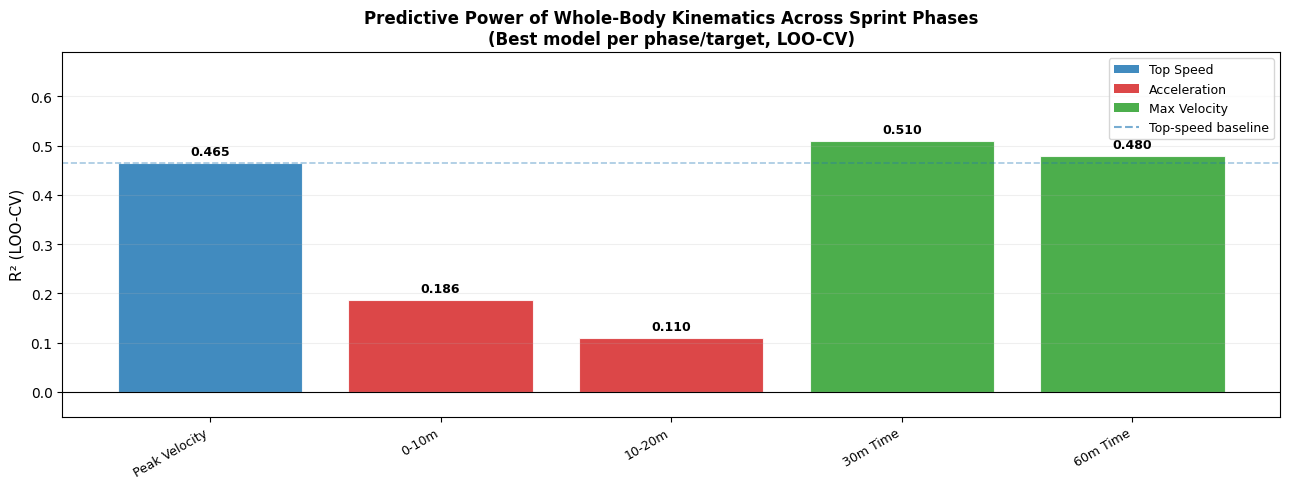

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Figures/cross_phase_r2_comparison.png


In [22]:
# ── Cross-Phase Comparison: Top Speed vs Acceleration ─────────────────────
# Summary table and bar chart comparing R^2_LOO across all sprint phases.

from matplotlib.patches import Patch

best_ts = results_df.iloc[0]   # already sorted by R2_LOO (top-speed, from Cell 42)

cross_rows = [{
    'Phase':      'Top Speed',
    'Target':     'Peak Velocity',
    'Best Model': f"{best_ts['Model']} [{best_ts['Features']}]",
    'R2_LOO':     float(best_ts['R2_LOO']),
    'RMSE':       float(best_ts['RMSE']),
}]

for icol, lbl in zip(INTERVAL_COLS[:2], INTERVAL_LABELS[:2]):
    sub = accel_model_df[accel_model_df['Target'] == lbl].sort_values('R2_LOO', ascending=False)
    if len(sub) == 0:
        continue
    b = sub.iloc[0]
    cross_rows.append({
        'Phase':      'Acceleration',
        'Target':     lbl,
        'Best Model': f"{b['Model']} [{b['Features']}]",
        'R2_LOO':     float(b['R2_LOO']),
        'RMSE':       float(b['RMSE']),
    })

# Add 30m and 60m cumulative predictions from new heatmap (hm_df)
# Best kinematic model for each target
for col_r2, tgt_lbl, phase_lbl in [
        ('R2_LOO_30m', '30m Time', 'Max Velocity'),
        ('R2_LOO_60m', '60m Time', 'Max Velocity')]:
    kin_rows = hm_df[~hm_df['predictor'].str.startswith('OLS')]
    kin_rows = kin_rows[kin_rows['predictor'].str.strip() != '\u2500' * 14]
    best_r2  = float(kin_rows[col_r2].max())
    best_mdl = str(kin_rows.loc[kin_rows[col_r2].idxmax(), 'predictor'])
    cross_rows.append({
        'Phase':      phase_lbl,
        'Target':     tgt_lbl,
        'Best Model': best_mdl,
        'R2_LOO':     best_r2,
        'RMSE':       np.nan,
    })

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv(DATA_DIR / 'cross_phase_comparison.csv', index=False)
print("Cross-Phase R\u00b2 Comparison:")
print(cross_df[['Phase','Target','Best Model','R2_LOO','RMSE']].to_string(index=False))

# ── Bar chart (KEY FIGURE) ─────────────────────────────────────────────────
phase_pal = {'Top Speed': '#1f77b4', 'Acceleration': '#d62728', 'Max Velocity': '#2ca02c'}
fig, ax   = plt.subplots(figsize=(13, 5))

seen_phases = set()
for i, row in cross_df.iterrows():
    col   = phase_pal.get(row['Phase'], '#888')
    label = row['Phase'] if row['Phase'] not in seen_phases else None
    seen_phases.add(row['Phase'])
    ax.bar(i, max(float(row['R2_LOO']), 0), color=col, alpha=0.85,
           edgecolor='white', lw=0.8, label=label)
    ax.text(i, max(float(row['R2_LOO']), 0) + 0.01, f"{float(row['R2_LOO']):.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(cross_df)))
ax.set_xticklabels([r['Target'] for _, r in cross_df.iterrows()],
                   rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(float(best_ts['R2_LOO']), ls='--', color='#1f77b4', alpha=0.4, lw=1.2,
           label=f"Top-speed baseline (R\u00b2={float(best_ts['R2_LOO']):.3f})")
ax.set_ylabel('R\u00b2 (LOO-CV)', fontsize=11)
ax.set_title('Predictive Power of Whole-Body Kinematics Across Sprint Phases\n'
             '(Best model per phase/target, LOO-CV)',
             fontsize=12, fontweight='bold')
ymax = max(float(cross_df['R2_LOO'].max()) + 0.18, 0.5)
ax.set_ylim(-0.05, ymax)

legend_els = [Patch(facecolor=v, label=k, alpha=0.85) for k, v in phase_pal.items()]
legend_els.append(plt.Line2D([0],[0], ls='--', color='#1f77b4', alpha=0.6,
                              label=f"Top-speed baseline"))
ax.legend(handles=legend_els, fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'cross_phase_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'cross_phase_r2_comparison.png'}")


---
# PART XI — Sex-Based Biomechanical Differences

With **16 male** and **15 female** participants, we test whether sprint kinematics and biomechanics
differ significantly between sexes using non-parametric Mann-Whitney U tests (appropriate for n=31).


In [23]:
# ── Sex-Based Statistical Tests (Mann-Whitney U) ──────────────────────────
from scipy.stats import mannwhitneyu

males   = bio_full[bio_full['sex'] == 'M']
females = bio_full[bio_full['sex'] == 'F']
print(f"Males: n={len(males)}   Females: n={len(females)}\n")

sex_records = []
for col in bio_numeric_cols:
    mv = males[col].dropna().values
    fv = females[col].dropna().values
    if len(mv) < 3 or len(fv) < 3:
        continue
    stat, pval = mannwhitneyu(mv, fv, alternative='two-sided')
    # Rank-biserial correlation (effect size)
    rbc = 1.0 - (2.0 * stat) / (len(mv) * len(fv))
    sex_records.append({
        'metric':          col,
        'mean_M':          round(float(mv.mean()), 4),
        'std_M':           round(float(mv.std()),  4),
        'mean_F':          round(float(fv.mean()), 4),
        'std_F':           round(float(fv.std()),  4),
        'U_stat':          round(float(stat), 1),
        'p_value':         round(float(pval), 4),
        'effect_size_rbc': round(float(rbc),  3),
        'significant':     bool(pval < 0.05),
    })

sex_diff_df = pd.DataFrame(sex_records).sort_values('p_value').reset_index(drop=True)
sex_diff_df.to_csv(DATA_DIR / 'sex_differences.csv', index=False)

print("Sex differences (sorted by p-value):")
print(sex_diff_df[['metric','mean_M','mean_F','p_value',
                   'effect_size_rbc','significant']].to_string(index=False))
n_sig = sex_diff_df['significant'].sum()
print(f"\n{n_sig}/{len(sex_diff_df)} metrics significantly different (p<0.05)")
print(f"Saved: {DATA_DIR / 'sex_differences.csv'}")


Males: n=15   Females: n=15

Sex differences (sorted by p-value):
                          metric  mean_M  mean_F  p_value  effect_size_rbc  significant
         top_speed_maintenance_m 32.2136 37.5135   0.0101            0.556         True
            strides_to_top_speed 10.8667 14.3333   0.1145            0.338        False
           stride1_dist_over_gct 25.0903 19.4362   0.1321           -0.333        False
       accel_distance_to_95pct_m 22.6310 21.2937   0.1585           -0.307        False
           stride2_dist_over_gct 39.8822 32.5319   0.1985           -0.280        False
        stride_freq_top_speed_hz  1.8204  1.7441   0.2394           -0.267        False
             avg_gct_top_speed_s  0.7010  0.5437   0.2435           -0.253        False
avg_vert_oscillation_top_speed_m  0.0598  0.0559   0.3724           -0.196        False
   avg_stride_length_top_speed_m  3.7336  3.7313   0.4070           -0.190        False

1/9 metrics significantly different (p<0.05)
Saved: /

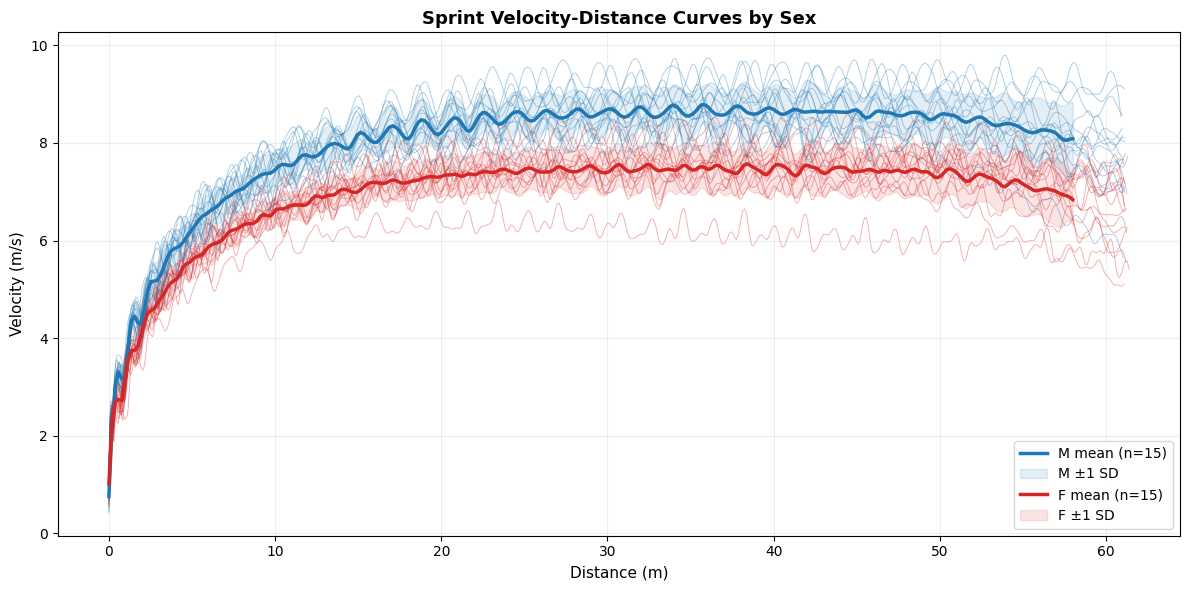

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Figures/velocity_curves_by_sex.png


In [24]:
# ── Velocity-Distance Curves by Sex ───────────────────────────────────────
from scipy.signal import savgol_filter as _sg

sex_lkp   = meta_df.set_index('participant_id')['sex'].to_dict()
SEX_COLS  = {'M': '#1f77b4', 'F': '#d62728'}

fig, ax = plt.subplots(figsize=(12, 6))
male_curves, female_curves = [], []

for pid, vt in velocity_traces.items():
    vel  = _sg(np.array(vt['velocity_ms']), window_length=9, polyorder=3)
    dist = np.array(vt['distance_m']); dist = dist - dist[0]
    sx   = sex_lkp.get(pid, '?')
    col  = SEX_COLS.get(sx, '#888')
    ax.plot(dist, vel, color=col, lw=0.7, alpha=0.35)
    if sx == 'M': male_curves.append((dist, vel))
    elif sx == 'F': female_curves.append((dist, vel))

# Mean + 1SD band per sex (interpolated to common distance grid)
d_grid = np.linspace(0, 58, 300)
for curves, sx, lw in [(male_curves,'M',2.5), (female_curves,'F',2.5)]:
    interps = [np.interp(d_grid, d, v, left=np.nan, right=np.nan)
               for d, v in curves if len(d) > 10]
    if len(interps) == 0:
        continue
    arr    = np.array(interps)
    mean_v = np.nanmean(arr, axis=0)
    sd_v   = np.nanstd(arr,  axis=0)
    if mean_v.ndim == 0 or len(mean_v) != len(d_grid):
        continue
    ax.plot(d_grid, mean_v, color=SEX_COLS[sx], lw=lw,
            label=f'{sx} mean (n={len(curves)})', zorder=5)
    ax.fill_between(d_grid, mean_v - sd_v, mean_v + sd_v,
                    color=SEX_COLS[sx], alpha=0.12, label=f'{sx} \u00b11 SD')

ax.set_xlabel('Distance (m)', fontsize=11)
ax.set_ylabel('Velocity (m/s)', fontsize=11)
ax.set_title('Sprint Velocity-Distance Curves by Sex', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'velocity_curves_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'velocity_curves_by_sex.png'}")


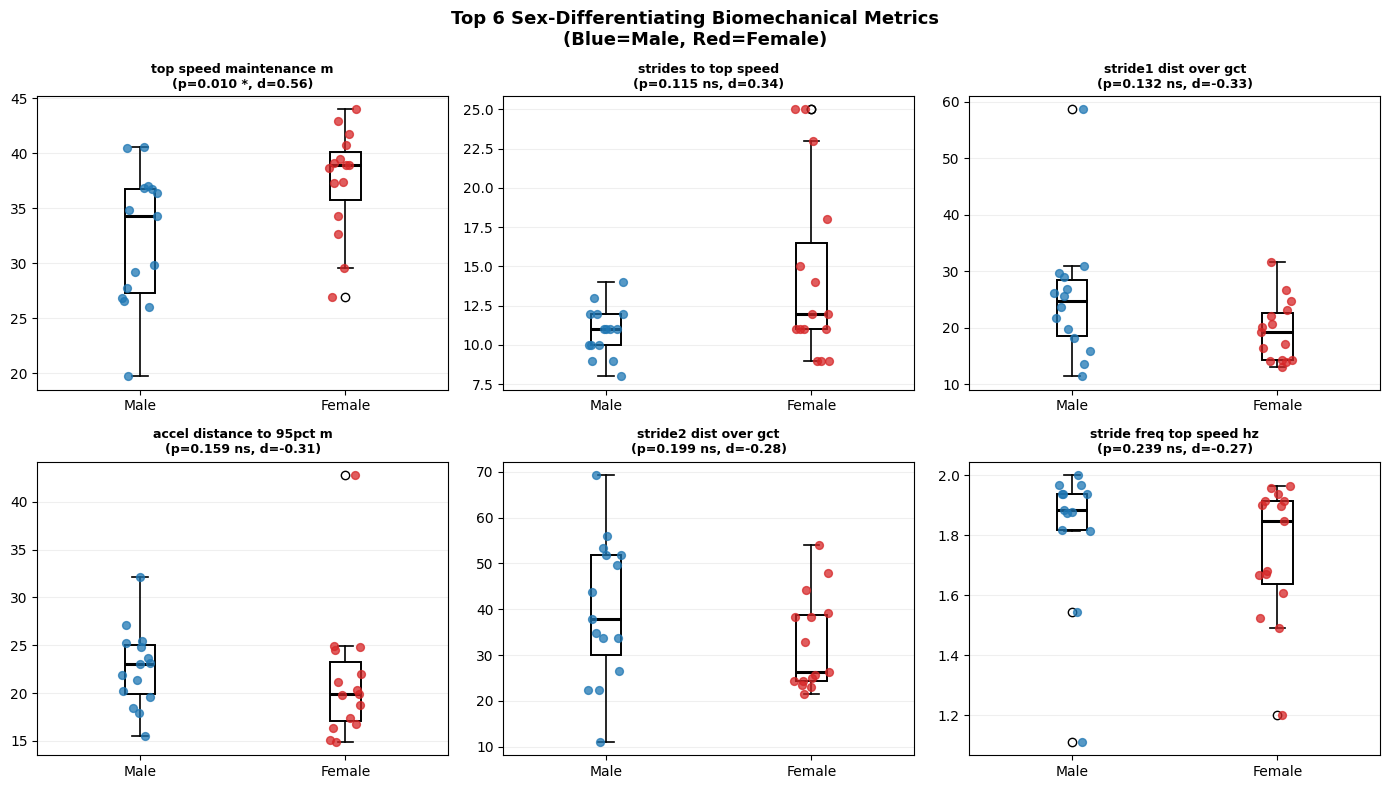

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Figures/sex_boxplots.png


In [25]:
# ── Sex-Stratified Box Plots (Top Differentiating Metrics) ────────────────
top6 = sex_diff_df.head(6)['metric'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

np.random.seed(RANDOM_SEED)
for i, metric in enumerate(top6):
    ax  = axes[i]
    mv  = bio_full.loc[bio_full['sex']=='M', metric].dropna().values
    fv  = bio_full.loc[bio_full['sex']=='F', metric].dropna().values
    bp  = ax.boxplot([mv, fv], labels=['Male','Female'], patch_artist=True,
                     boxprops=dict(facecolor='none', linewidth=1.4),
                     medianprops=dict(color='black', lw=2.2),
                     whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2))
    # Jittered scatter overlay
    ax.scatter(1 + np.random.uniform(-0.09,0.09,len(mv)),
               mv, color='#1f77b4', alpha=0.75, s=32, zorder=3)
    ax.scatter(2 + np.random.uniform(-0.09,0.09,len(fv)),
               fv, color='#d62728', alpha=0.75, s=32, zorder=3)
    row  = sex_diff_df[sex_diff_df['metric'] == metric].iloc[0]
    pval = row['p_value']; rbc = row['effect_size_rbc']
    sig  = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'ns'))
    ax.set_title(f"{metric.replace('_',' ')}\n(p={pval:.3f} {sig}, d={rbc:.2f})",
                 fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)

for j in range(len(top6), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 6 Sex-Differentiating Biomechanical Metrics\n(Blue=Male, Red=Female)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'sex_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'sex_boxplots.png'}")


In [26]:
# ── Sex as Binary Covariate in Prediction ─────────────────────────────────
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score
import warnings

np.random.seed(RANDOM_SEED)

sex_binary    = (meta_df['sex'] == 'M').astype(float).values   # M=1, F=0
X_B_with_sex  = np.column_stack([X_B, sex_binary])

print("Effect of sex covariate on R\u00b2_LOO (bio features):\n")
print(f"{'Model':<18} {'Without Sex':>13} {'With Sex':>11} {'Delta':>9}")
print("-" * 55)

sex_models = [
    ('Ridge',   Pipeline([('sc', StandardScaler()),
                          ('m', RidgeCV(alphas=np.logspace(-3,3,30)))])),
    ('RF',      Pipeline([('sc', StandardScaler()),
                          ('m', RandomForestRegressor(n_estimators=300, max_depth=3,
                                                       min_samples_leaf=3,
                                                       random_state=RANDOM_SEED))])),
    ('kNN-5',   Pipeline([('sc', StandardScaler()),
                          ('m', KNeighborsRegressor(n_neighbors=5))])),
]

loo_sx = LeaveOneOut()
for mname, pipe in sex_models:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        yp_no  = cross_val_predict(pipe, X_B,          y, cv=loo_sx)
        yp_sex = cross_val_predict(pipe, X_B_with_sex, y, cv=loo_sx)
    r2_no  = r2_score(y, yp_no)
    r2_sex = r2_score(y, yp_sex)
    delta  = r2_sex - r2_no
    sign   = '+' if delta >= 0 else ''
    print(f"  {mname:<16} {r2_no:>13.4f} {r2_sex:>11.4f} {sign}{delta:>8.4f}")


Effect of sex covariate on R²_LOO (bio features):

Model                Without Sex    With Sex     Delta
-------------------------------------------------------
  Ridge                   0.0390      0.4438 +  0.4048


  RF                      0.1016      0.6078 +  0.5062
  kNN-5                   0.0004      0.5099 +  0.5095


---
# PART XIII — Results Narrative for Sports Analysts

Translating statistical findings into actionable insights for coaches and sports scientists.


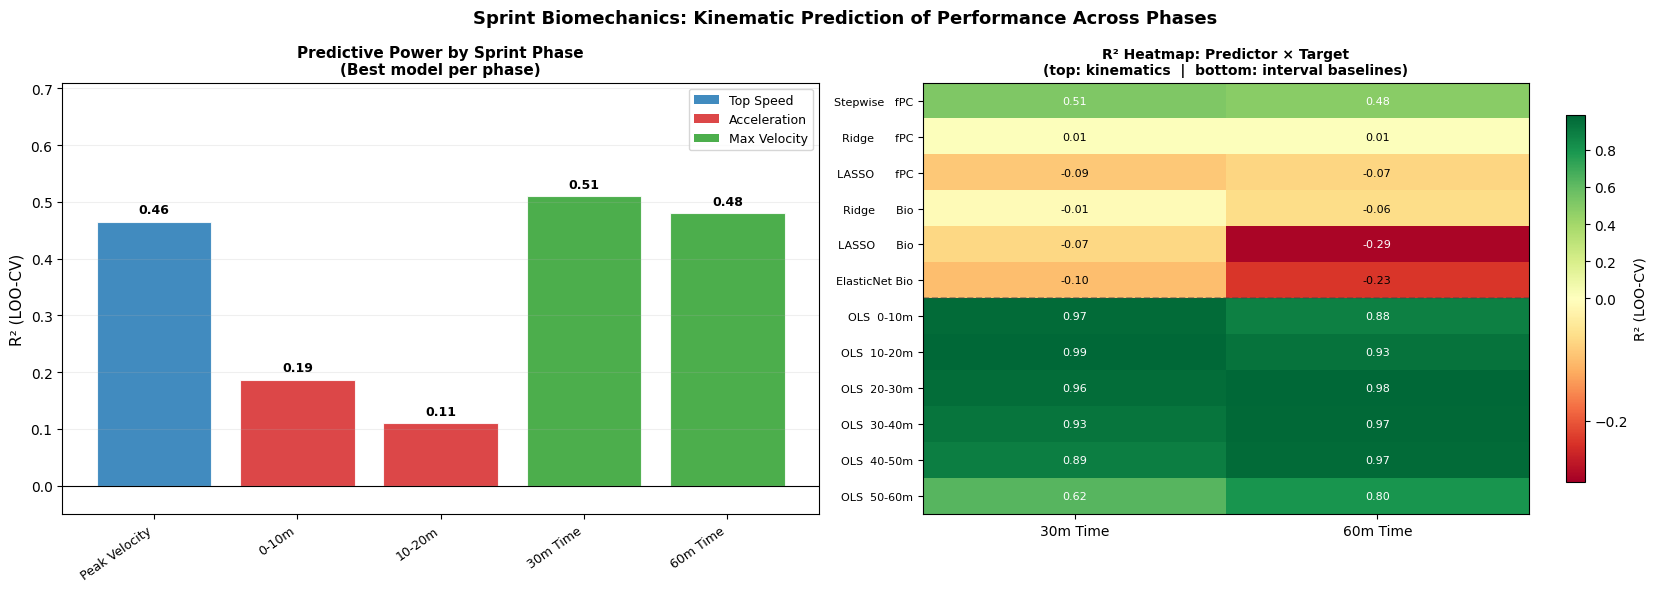

Saved: /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Figures/phase_r2_summary.png


In [27]:
# ── Phase R^2 Summary Figure (KEY DELIVERABLE) ────────────────────────────
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Left: Cross-phase bar chart ────────────────────────────────────────────
ax = axes[0]
phase_pal = {'Top Speed': '#1f77b4', 'Acceleration': '#d62728', 'Max Velocity': '#2ca02c'}
seen_ph   = set()
for i, (_, row) in enumerate(cross_df.iterrows()):
    col   = phase_pal.get(row['Phase'], '#888')
    label = row['Phase'] if row['Phase'] not in seen_ph else None
    seen_ph.add(row['Phase'])
    ax.bar(i, max(float(row['R2_LOO']), 0), color=col, alpha=0.85,
           edgecolor='white', lw=0.8, label=label)
    ax.text(i, max(float(row['R2_LOO']), 0) + 0.01,
            f"{float(row['R2_LOO']):.2f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(cross_df)))
ax.set_xticklabels([r['Target'] for _, r in cross_df.iterrows()],
                   rotation=35, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('R\u00b2 (LOO-CV)', fontsize=11)
ax.set_title('Predictive Power by Sprint Phase\n(Best model per phase)', fontsize=11, fontweight='bold')
ymax_l = max(float(cross_df['R2_LOO'].max()) + 0.20, 0.5)
ax.set_ylim(-0.05, ymax_l)
legend_els = [Patch(facecolor=v, label=k, alpha=0.85) for k, v in phase_pal.items()]
ax.legend(handles=legend_els, fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.2)

# ── Right: Phase heatmap (predictor × 30m/60m R²) ──────────────────────────
ax2 = axes[1]
hm_plot = hm_df[hm_df['predictor'].str.strip() != '\u2500'*14].copy()
hm_v2   = hm_plot[['R2_LOO_30m','R2_LOO_60m']].values.astype(float)
import matplotlib.colors as _mc2
_norm2 = _mc2.TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=max(0.5, float(np.nanmax(hm_v2))))
im   = ax2.imshow(hm_v2, cmap='RdYlGn', norm=_norm2, aspect='auto')
plt.colorbar(im, ax=ax2, label='R\u00b2 (LOO-CV)', shrink=0.85)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['30m Time', '60m Time'], fontsize=10)
ax2.set_yticks(range(len(hm_plot)))
ax2.set_yticklabels(hm_plot['predictor'].tolist(), fontsize=8)
n_kin78 = hm_df[~hm_df['predictor'].str.startswith('OLS') & (hm_df['predictor'].str.strip() != '\u2500'*14)].shape[0]
ax2.axhline(n_kin78 - 0.5, color='#444', lw=1.2, ls='--', alpha=0.5)
for i in range(hm_v2.shape[0]):
    for j in range(hm_v2.shape[1]):
        v   = hm_v2[i, j]
        txt = f'{v:.2f}' if not np.isnan(v) else '-'
        col = 'white' if abs(float(v)) > 0.27 else 'black'
        ax2.text(j, i, txt, ha='center', va='center', fontsize=8, color=col)
ax2.set_title('R\u00b2 Heatmap: Predictor \u00d7 Target\n(top: kinematics  |  bottom: interval baselines)',
              fontsize=10, fontweight='bold')

fig.suptitle('Sprint Biomechanics: Kinematic Prediction of Performance Across Phases',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'phase_r2_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / 'phase_r2_summary.png'}")


## Coaching Implications & Conclusions

- **Phase specificity**: accel kinematics predict 30 m time; top-speed kinematics predict 60 m time. Train each phase's mechanics on its own terms.
- **Top predictors** (Ridge ∩ SHAP): see Section VI table — these are the metrics worth measuring in athlete profiling.
- **PC interpretation**: every PC referenced above is visualised in `Outputs/Figures/top-speed_fpca_PC_*.png` and `accel_fpca_PC_*.png` (shape mode + r-vs-velocity, Python-generated).
- **Sex effects** (Section VII): differences are real but explain less variance than phase-specific kinematic features.
- **Sample size caveat**: n = 30 limits model selection confidence; LOO-CV R² is the only metric trusted here.
- **Next step**: external validation cohort + within-subject test–retest to lock in the top predictors.
